# Elliptic++ Actors (Wallet Addresses) — Full Replication Pipeline (v3)

**Paper:** *Demystifying Fraudulent Transactions and Illicit Nodes in the Bitcoin Network for Financial Forensics*  
**Authors:** Youssef Elmougy, Ling Liu — Georgia Institute of Technology (KDD '23)  
**Dataset:** https://www.github.com/git-disl/EllipticPlusPlus

| Section | Content |
|---------|---------|
| 0 | Google Colab Setup |
| 1 | Imports & Data Loading |
| 2 | Dataset Overview |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Dataset Statistics (Figs 2, 9 · Tables 5, 6) |
| 5 | Graph Visualization — AddrTx & ActorInteraction Graphs |
| 6 | Feature Correlation Analysis (Fig 8) |
| 7 | Preprocessing — Split · Scaling · Class Weights |
| 8 | ML Classification — LR, RF, MLP, XGB |
| 9 | Cross-Validation & Hyperparameter Tuning |
| 10 | Feature Importance Analysis (Validation-Set Based) |
| 11 | Feature-Refined Models |
| 12 | Final Results Summary |

---
**Required CSV files** (place in your Google Drive folder):
- `wallets_features.csv` · `wallets_classes.csv` · `AddrAddr_edgelist.csv`
- `AddrTx_edgelist.csv` · `TxAddr_edgelist.csv` · `wallets_features_classes_combined.csv`


## Section 0: Google Colab Setup

In [ ]:
# Install packages not pre-installed in Colab
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

pip_install("xgboost")
pip_install("eli5")
pip_install("imbalanced-learn")   # for SMOTE (optional, available if needed)
pip_install("shap")               # for SHAP explainability
pip_install("tqdm")               # for progress bars
print("All packages ready.")


All packages ready.


In [ ]:
# Mount Google Drive and set data directory
from google.colab import drive
drive.mount('/content/drive')

# ── UPDATE THIS PATH to the folder containing your 6 CSV files ───────────────
DATA_DIR = '/content/drive/MyDrive/Elliptic++ Dataset/'   # <-- CHANGE ME

import os
assert os.path.isdir(DATA_DIR), f"Folder not found: {DATA_DIR}. Please update DATA_DIR."
print(f"DATA_DIR confirmed: {DATA_DIR}")


Mounted at /content/drive
DATA_DIR confirmed: /content/drive/MyDrive/Elliptic++ Dataset/


## Section 1: Imports & Data Loading

In [ ]:
# ── Core libraries ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import networkx as nx
import plotly.graph_objs as go
import math
from collections import Counter
from statistics import mean, median

# Colab: enable Plotly inline rendering
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (precision_recall_fscore_support, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              matthews_corrcoef, roc_auc_score,
                              RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import compute_sample_weight
from sklearn.base import clone

# ── XGBoost ───────────────────────────────────────────────────────────────────
import xgboost as xgb

# ── SHAP ──────────────────────────────────────────────────────────────────────
import shap

# ── Progress bars ─────────────────────────────────────────────────────────────
from tqdm.auto import tqdm

print("All imports successful.")


All imports successful.


In [ ]:
# ── Load CSV files with memory-efficient dtypes ──────────────────────────────
print("Loading files...")

df_wallets_features = pd.read_csv(DATA_DIR + "wallets_features.csv")

df_wallets_classes = pd.read_csv(
    DATA_DIR + "wallets_classes.csv",
    dtype={"address": "string", "class": "int8"}
)

df_AddrAddr_edgelist = pd.read_csv(
    DATA_DIR + "AddrAddr_edgelist.csv",
    dtype={"input_address": "string", "output_address": "string"}
)

df_AddrTx_edgelist = pd.read_csv(
    DATA_DIR + "AddrTx_edgelist.csv",
    dtype={"input_address": "string", "txId": "int32"}
)

df_TxAddr_edgelist = pd.read_csv(
    DATA_DIR + "TxAddr_edgelist.csv",
    dtype={"txId": "int32", "output_address": "string"}
)

df_wallets_features_classes_combined = pd.read_csv(
    DATA_DIR + "wallets_features_classes_combined.csv"
)

print("All files loaded!")
print(f"  wallets_features shape               : {df_wallets_features.shape}")
print(f"  wallets_classes shape                : {df_wallets_classes.shape}")
print(f"  AddrAddr_edgelist shape              : {df_AddrAddr_edgelist.shape}")
print(f"  AddrTx_edgelist shape                : {df_AddrTx_edgelist.shape}")
print(f"  TxAddr_edgelist shape                : {df_TxAddr_edgelist.shape}")
print(f"  wallets_features_classes_combined    : {df_wallets_features_classes_combined.shape}")


Loading files...
All files loaded!
  wallets_features shape               : (1268260, 57)
  wallets_classes shape                : (822942, 2)
  AddrAddr_edgelist shape              : (2868964, 2)
  AddrTx_edgelist shape                : (477117, 2)
  TxAddr_edgelist shape                : (837124, 2)
  wallets_features_classes_combined    : (1268260, 58)


---
## Section 2: Dataset Overview

The actors dataset contains **822,942 Bitcoin wallet addresses**, each described with **56 features**.

| File | Description |
|------|-------------|
| `wallets_features.csv` | 56 features per address per time step |
| `wallets_classes.csv` | Labels: 1=illicit, 2=licit, 3=unknown |
| `AddrAddr_edgelist.csv` | Actor Interaction Graph (address→address) |
| `AddrTx_edgelist.csv` | Address→Transaction edges |
| `TxAddr_edgelist.csv` | Transaction→Address edges |


In [ ]:
# Example actor — show raw data across all files (Table 3 in paper)
EXAMPLE_ADDR = "39sfuA8pY4UfybgEZi7uvA13jkGzZpsg5K"

print("wallets_features.csv for example address:")
display(df_wallets_features[df_wallets_features["address"] == EXAMPLE_ADDR])

print("\nwallets_classes.csv for example address:")
display(df_wallets_classes[df_wallets_classes["address"] == EXAMPLE_ADDR])

print("\nAddrAddr_edgelist.csv for example address:")
display(df_AddrAddr_edgelist[
    (df_AddrAddr_edgelist["input_address"] == EXAMPLE_ADDR) |
    (df_AddrAddr_edgelist["output_address"] == EXAMPLE_ADDR)
])


wallets_features.csv for example address:


,address,Time step,num_txs_as_sender,num_txs_as receiver,first_block_appeared_in,last_block_appeared_in,lifetime_in_blocks,total_txs,first_sent_block,first_received_block,...,blocks_btwn_output_txs_min,blocks_btwn_output_txs_max,blocks_btwn_output_txs_mean,blocks_btwn_output_txs_median,num_addr_transacted_multiple,transacted_w_address_total,transacted_w_address_min,transacted_w_address_max,transacted_w_address_mean,transacted_w_address_median
1149250,39sfuA8pY4UfybgEZi7uvA13jkGzZpsg5K,23,420.0,1.0,435559.0,453704.0,18145.0,421.0,435559.0,451682.0,...,0.0,0.0,0.0,0.0,17.0,495.0,1.0,3.0,1.046512,1.0
1149251,39sfuA8pY4UfybgEZi7uvA13jkGzZpsg5K,23,420.0,1.0,435559.0,453704.0,18145.0,421.0,435559.0,451682.0,...,0.0,0.0,0.0,0.0,17.0,495.0,1.0,3.0,1.046512,1.0
1149252,39sfuA8pY4UfybgEZi7uvA13jkGzZpsg5K,23,420.0,1.0,435559.0,453704.0,18145.0,421.0,435559.0,451682.0,...,0.0,0.0,0.0,0.0,17.0,495.0,1.0,3.0,1.046512,1.0
1149253,39sfuA8pY4UfybgEZi7uvA13jkGzZpsg5K,23,420.0,1.0,435559.0,453704.0,18145.0,421.0,435559.0,451682.0,...,0.0,0.0,0.0,0.0,17.0,495.0,1.0,3.0,1.046512,1.0
1149254,39sfuA8pY4UfybgEZi7uvA13jkGzZpsg5K,24,420.0,1.0,435559.0,453704.0,18145.0,421.0,435559.0,451682.0,...,0.0,0.0,0.0,0.0,17.0,495.0,1.0,3.0,1.046512,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1149666,39sfuA8pY4UfybgEZi7uvA13jkGzZpsg5K,32,420.0,1.0,435559.0,453704.0,18145.0,421.0,435559.0,451682.0,...,0.0,0.0,0.0,0.0,17.0,495.0,1.0,3.0,1.046512,1.0
1149667,39sfuA8pY4UfybgEZi7uvA13jkGzZpsg5K,32,420.0,1.0,435559.0,453704.0,18145.0,421.0,435559.0,451682.0,...,0.0,0.0,0.0,0.0,17.0,495.0,1.0,3.0,1.046512,1.0
1149668,39sfuA8pY4UfybgEZi7uvA13jkGzZpsg5K,32,420.0,1.0,435559.0,453704.0,18145.0,421.0,435559.0,451682.0,...,0.0,0.0,0.0,0.0,17.0,495.0,1.0,3.0,1.046512,1.0
1149669,39sfuA8pY4UfybgEZi7uvA13jkGzZpsg5K,32,420.0,1.0,435559.0,453704.0,18145.0,421.0,435559.0,451682.0,...,0.0,0.0,0.0,0.0,17.0,495.0,1.0,3.0,1.046512,1.0



wallets_classes.csv for example address:


,address,class
745591,39sfuA8pY4UfybgEZi7uvA13jkGzZpsg5K,1



AddrAddr_edgelist.csv for example address:


,input_address,output_address
1317522,39sfuA8pY4UfybgEZi7uvA13jkGzZpsg5K,131fHSzsK1eQJp7bC94JVWZqJ2JcdR5UfS
1317523,39sfuA8pY4UfybgEZi7uvA13jkGzZpsg5K,39sfuA8pY4UfybgEZi7uvA13jkGzZpsg5K
1317634,39sfuA8pY4UfybgEZi7uvA13jkGzZpsg5K,1FCw4XNAP6xeWMF4o3RaNENguE9qFumgpn
1317635,39sfuA8pY4UfybgEZi7uvA13jkGzZpsg5K,39sfuA8pY4UfybgEZi7uvA13jkGzZpsg5K
1317644,39sfuA8pY4UfybgEZi7uvA13jkGzZpsg5K,39sfuA8pY4UfybgEZi7uvA13jkGzZpsg5K
...,...,...
1592119,39sfuA8pY4UfybgEZi7uvA13jkGzZpsg5K,39sfuA8pY4UfybgEZi7uvA13jkGzZpsg5K
1592120,39sfuA8pY4UfybgEZi7uvA13jkGzZpsg5K,39sfuA8pY4UfybgEZi7uvA13jkGzZpsg5K
1592121,39sfuA8pY4UfybgEZi7uvA13jkGzZpsg5K,32ZkfqSGoxdx5UGo8YQp1tFhSv8R982Usk
1592122,39sfuA8pY4UfybgEZi7uvA13jkGzZpsg5K,39sfuA8pY4UfybgEZi7uvA13jkGzZpsg5K


In [ ]:
# All 56 feature names (Table 4 in paper)
print("Actors dataset feature columns:")
for i, col in enumerate(df_wallets_features.columns):
    print(f"  [{i:2d}] {col}")


Actors dataset feature columns:
  [ 0] address
  [ 1] Time step
  [ 2] num_txs_as_sender
  [ 3] num_txs_as receiver
  [ 4] first_block_appeared_in
  [ 5] last_block_appeared_in
  [ 6] lifetime_in_blocks
  [ 7] total_txs
  [ 8] first_sent_block
  [ 9] first_received_block
  [10] num_timesteps_appeared_in
  [11] btc_transacted_total
  [12] btc_transacted_min
  [13] btc_transacted_max
  [14] btc_transacted_mean
  [15] btc_transacted_median
  [16] btc_sent_total
  [17] btc_sent_min
  [18] btc_sent_max
  [19] btc_sent_mean
  [20] btc_sent_median
  [21] btc_received_total
  [22] btc_received_min
  [23] btc_received_max
  [24] btc_received_mean
  [25] btc_received_median
  [26] fees_total
  [27] fees_min
  [28] fees_max
  [29] fees_mean
  [30] fees_median
  [31] fees_as_share_total
  [32] fees_as_share_min
  [33] fees_as_share_max
  [34] fees_as_share_mean
  [35] fees_as_share_median
  [36] blocks_btwn_txs_total
  [37] blocks_btwn_txs_min
  [38] blocks_btwn_txs_max
  [39] blocks_btwn_txs_mean

---
## Section 3: Exploratory Data Analysis (EDA)

A dedicated EDA to understand feature distributions, class separability,
missing values, and correlations before any modelling.


In [ ]:
# ── 3.1 Basic summary statistics per class ───────────────────────────────────
df_eda = df_wallets_features_classes_combined.copy()
df_eda["class_label"] = df_eda["class"].map({1: "illicit", 2: "licit", 3: "unknown"})

feature_cols_eda = [c for c in df_eda.columns
                    if c not in ["address", "class", "class_label", "Time step",
                                 "num_timesteps_appeared_in"]]

print(f"Total feature columns available for EDA: {len(feature_cols_eda)}")
print("\nClass counts:")
print(df_eda["class_label"].value_counts())
print("\nSummary statistics (illicit class only):")
display(df_eda[df_eda["class_label"] == "illicit"][feature_cols_eda].describe().T
        .sort_values("mean", ascending=False).head(15).round(4))


Total feature columns available for EDA: 54

Class counts:
class_label
unknown    900788
licit      338871
illicit     28601
Name: count, dtype: int64

Summary statistics (illicit class only):


,count,mean,std,min,25%,50%,75%,max
last_block_appeared_in,28601.0,445632.9383,22703.6770,391202.0,431526.0000,441606.0,461766.0,487975.0
first_block_appeared_in,28601.0,444456.5360,22884.5821,391200.0,431523.0000,441600.0,461764.0,487975.0
first_sent_block,28601.0,396672.2823,140147.0673,0.0,421444.0000,439587.0,459750.0,487975.0
first_received_block,28601.0,388322.3909,147616.1663,0.0,419426.0000,439584.0,457730.0,487975.0
blocks_btwn_txs_total,28601.0,1176.4331,6351.2493,0.0,1.0000,1.0,3.0,82646.0
lifetime_in_blocks,28601.0,1176.4023,6351.0739,0.0,1.0000,1.0,3.0,82646.0
blocks_btwn_output_txs_total,28601.0,730.1488,5241.3804,0.0,0.0000,0.0,0.0,82646.0
blocks_btwn_txs_max,28601.0,634.3252,3620.7596,0.0,1.0000,1.0,3.0,76598.0
blocks_btwn_input_txs_total,28601.0,548.7854,3634.3231,0.0,0.0000,0.0,0.0,76610.0
blocks_btwn_output_txs_max,28601.0,443.4648,3137.0933,0.0,0.0000,0.0,0.0,66528.0


In [ ]:
# ── 3.2 Missing values check ─────────────────────────────────────────────────
missing = df_eda[feature_cols_eda].isnull().sum()
missing_pct = (missing / len(df_eda) * 100).round(2)
missing_report = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_report = missing_report[missing_report["Missing Count"] > 0]

if missing_report.empty:
    print("No missing values found in any feature column.")
else:
    print("Columns with missing values:")
    display(missing_report)


No missing values found in any feature column.


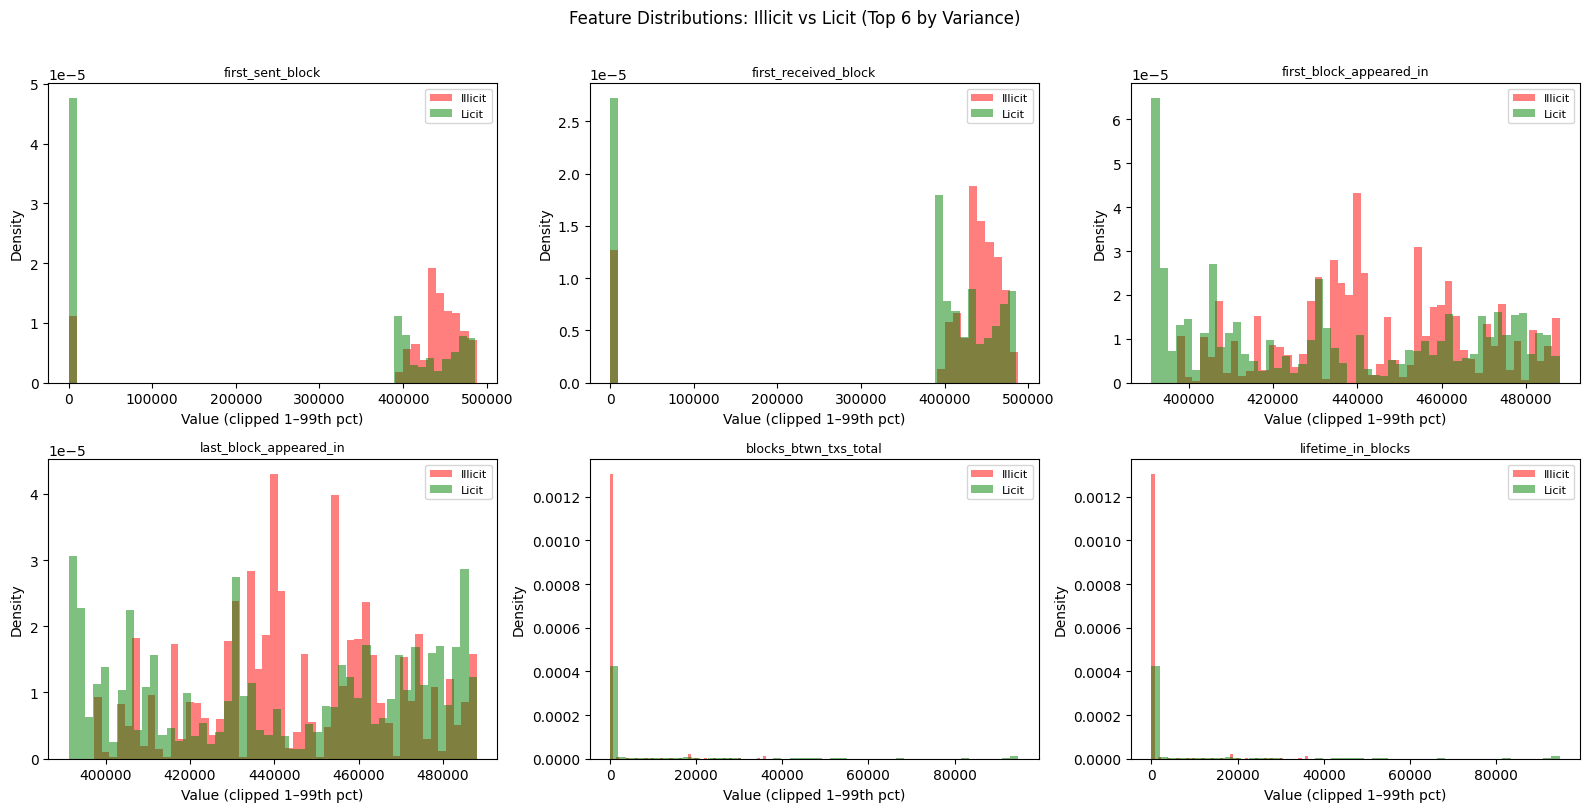

In [ ]:
# ── 3.3 Feature distributions — illicit vs licit (top 6 by variance) ─────────
# Select top 6 features by variance across labelled addresses only
df_labelled_eda = df_eda[df_eda["class"].isin([1, 2])].copy()
top_var_features = (df_labelled_eda[feature_cols_eda]
                    .var().sort_values(ascending=False).head(6).index.tolist())

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, feat in zip(axes, top_var_features):
    for cls, color, label in [(1, "red", "Illicit"), (2, "green", "Licit")]:
        vals = df_labelled_eda[df_labelled_eda["class"] == cls][feat].dropna()
        # Clip extreme outliers for visibility
        p1, p99 = vals.quantile(0.01), vals.quantile(0.99)
        vals_clipped = vals.clip(p1, p99)
        ax.hist(vals_clipped, bins=50, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel("Value (clipped 1–99th pct)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Feature Distributions: Illicit vs Licit (Top 6 by Variance)", y=1.01)
plt.tight_layout()
plt.show()


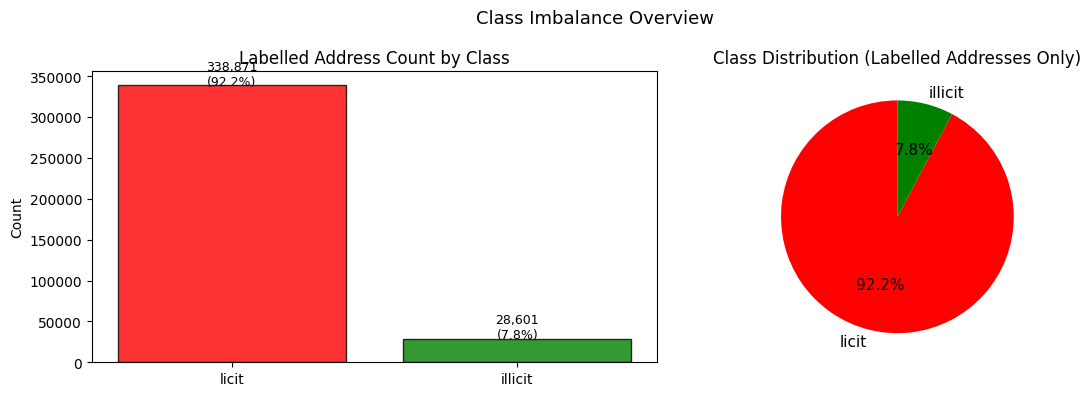


Imbalance ratio (licit:illicit) = 338,871 : 28,601
  = 11.8:1


In [ ]:
# ── 3.4 Class imbalance visualisation ────────────────────────────────────────
# Show the imbalance in the labelled set (unknowns excluded)
class_counts = df_labelled_eda["class_label"].value_counts()
total_labelled = class_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(class_counts.index, class_counts.values,
            color=["red", "green"], edgecolor="black", alpha=0.8)
axes[0].set_title("Labelled Address Count by Class")
axes[0].set_ylabel("Count")
for i, (idx, val) in enumerate(class_counts.items()):
    label_text = f"{val:,}\n({val/total_labelled*100:.1f}%)"
    axes[0].text(i, val + 500, label_text, ha="center", fontsize=9)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index,
            colors=["red", "green"], autopct="%1.1f%%", startangle=90,
            textprops={"fontsize": 11})
axes[1].set_title("Class Distribution (Labelled Addresses Only)")

plt.suptitle("Class Imbalance Overview", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nImbalance ratio (licit:illicit) = {class_counts['licit']:,} : {class_counts['illicit']:,}")
print(f"  = {class_counts['licit']/class_counts['illicit']:.1f}:1")


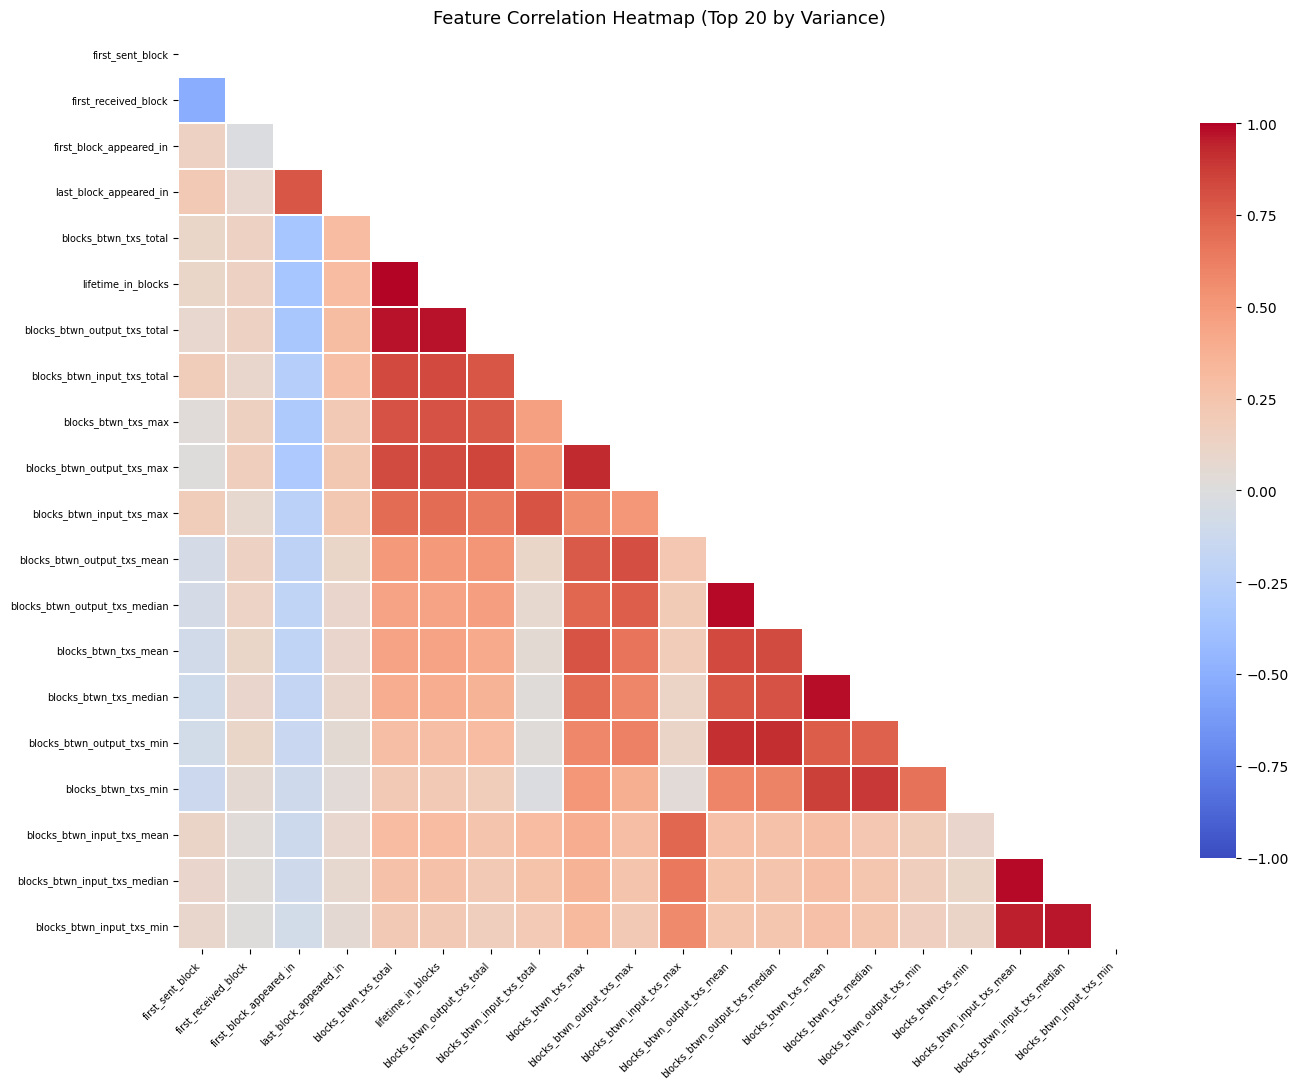

In [ ]:
# ── 3.5 Correlation heatmap — top 20 features (labelled addresses) ───────────
corr_matrix = df_labelled_eda[feature_cols_eda].corr()

# Select top 20 most variable features for readability
top20 = (df_labelled_eda[feature_cols_eda]
         .var().sort_values(ascending=False).head(20).index.tolist())
corr_sub = corr_matrix.loc[top20, top20]

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_sub, dtype=bool))
sns.heatmap(corr_sub, mask=mask, annot=False, cmap="coolwarm",
            center=0, linewidths=0.3, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap (Top 20 by Variance)", fontsize=13)
plt.xticks(fontsize=7, rotation=45, ha="right")
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()


/tmp/ipykernel_2010/4095827126.py:11: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

/tmp/ipykernel_2010/4095827126.py:11: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

/tmp/ipykernel_2010/4095827126.py:11: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

/tmp/ipykernel_2010/4095827126.py:11: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

/tmp/ipykernel_2010/4095827126.py:11: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; suppor

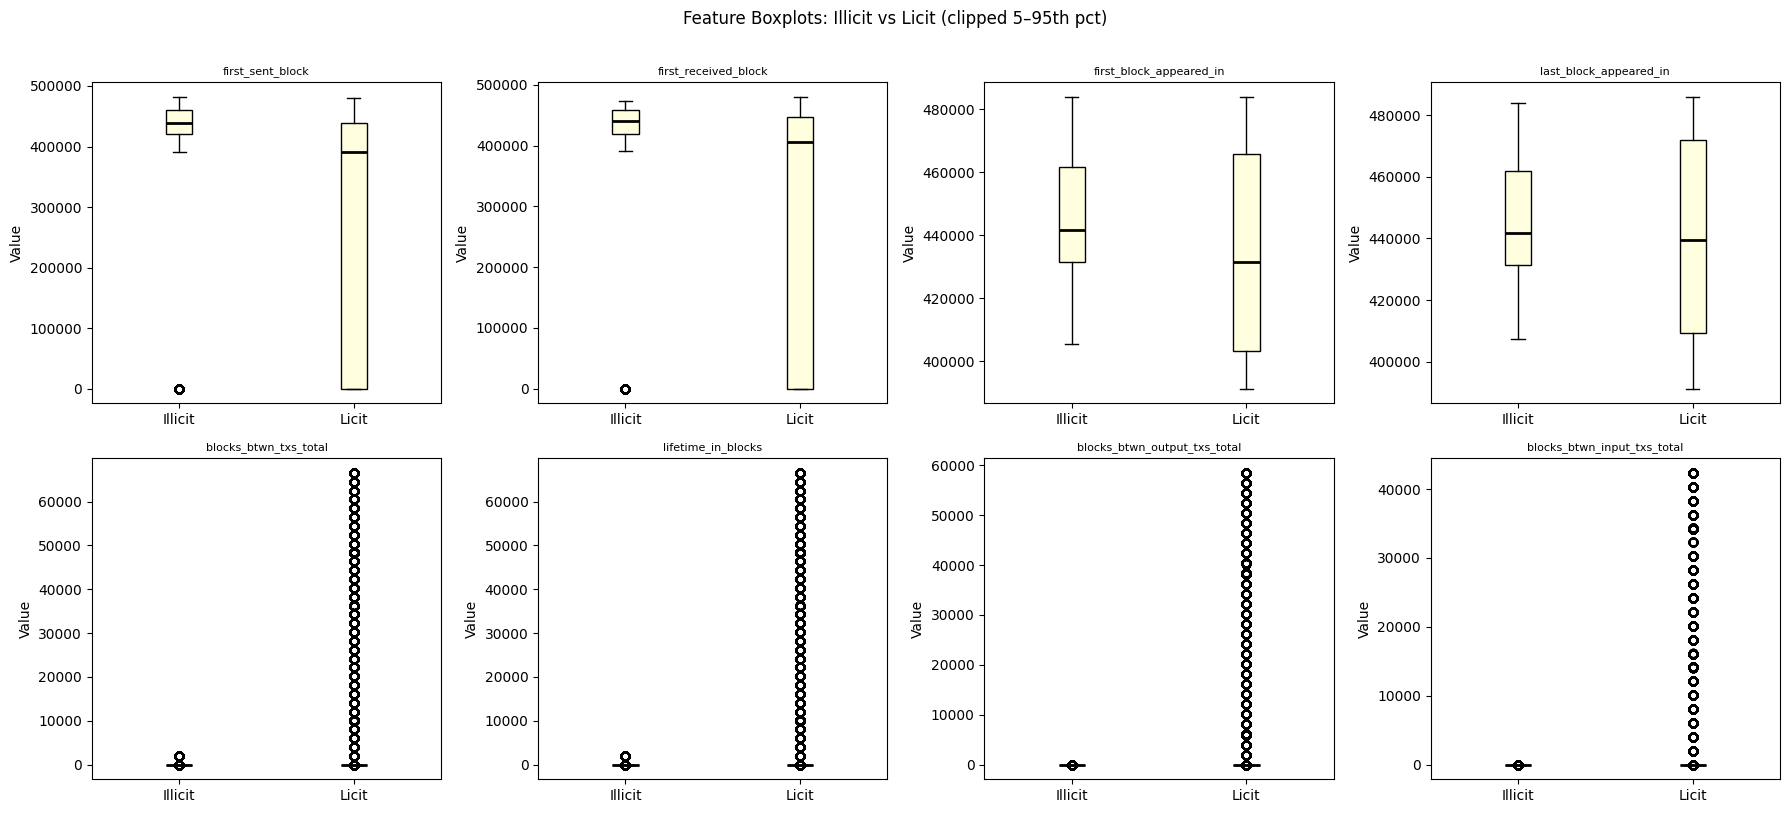

In [ ]:
# ── 3.6 Boxplots — top 8 features, illicit vs licit ─────────────────────────
top8 = (df_labelled_eda[feature_cols_eda]
        .var().sort_values(ascending=False).head(8).index.tolist())

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, feat in zip(axes, top8):
    data_illicit = df_labelled_eda[df_labelled_eda["class"] == 1][feat].dropna()
    data_licit   = df_labelled_eda[df_labelled_eda["class"] == 2][feat].dropna()
    ax.boxplot([data_illicit.clip(*data_illicit.quantile([0.05, 0.95])),
                data_licit.clip(*data_licit.quantile([0.05, 0.95]))],
               labels=["Illicit", "Licit"],
               patch_artist=True,
               boxprops=dict(facecolor="lightyellow"),
               medianprops=dict(color="black", linewidth=2))
    ax.set_title(feat, fontsize=8)
    ax.set_ylabel("Value")

plt.suptitle("Feature Boxplots: Illicit vs Licit (clipped 5–95th pct)", y=1.01)
plt.tight_layout()
plt.show()


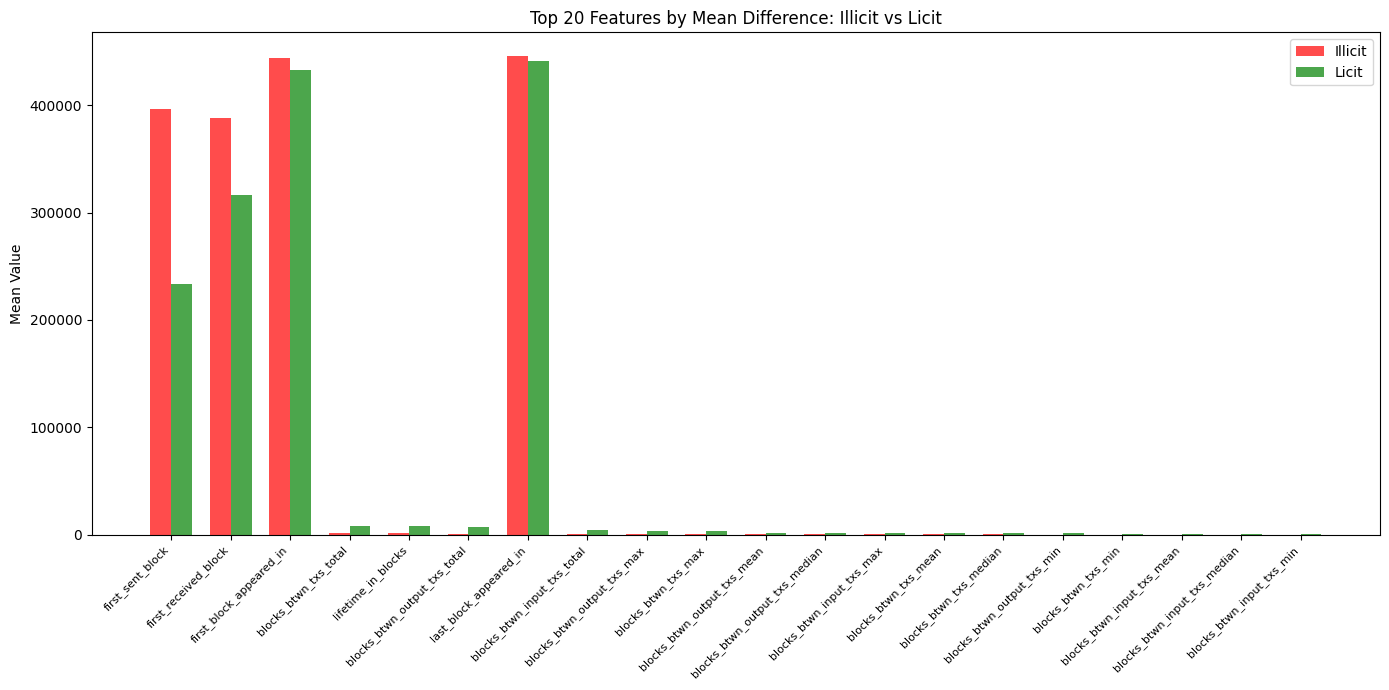

In [ ]:
# ── 3.7 Feature means: illicit vs licit — sorted by discriminative power ──────
means = (df_labelled_eda.groupby("class_label")[feature_cols_eda]
         .mean().T)

# Discriminative power = absolute difference between class means
means["abs_diff"] = (means["illicit"] - means["licit"]).abs()
means_sorted = means.sort_values("abs_diff", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(means_sorted))
width = 0.35
ax.bar(x - width/2, means_sorted["illicit"], width,
       label="Illicit", color="red", alpha=0.7)
ax.bar(x + width/2, means_sorted["licit"], width,
       label="Licit", color="green", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(means_sorted.index, rotation=45, ha="right", fontsize=8)
ax.set_title("Top 20 Features by Mean Difference: Illicit vs Licit")
ax.set_ylabel("Mean Value")
ax.legend()
plt.tight_layout()
plt.show()


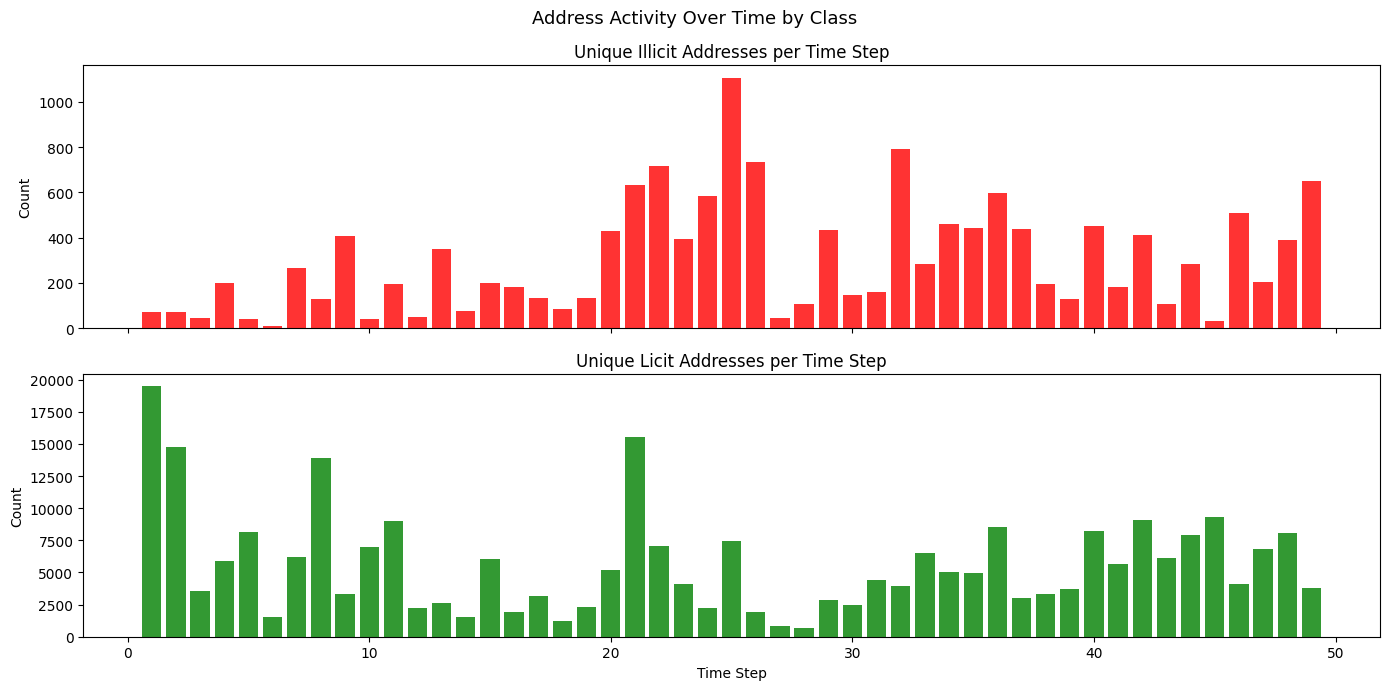

Mean illicit addresses per time step : 300.4
Mean licit addresses per time step   : 5646.9
Time steps with zero illicit activity: 0


In [ ]:
# ── 3.8 Time step activity — illicit actors ──────────────────────────────────
illicit_ts = (df_eda[df_eda["class"] == 1]
              .groupby("Time step")["address"].nunique())
licit_ts   = (df_eda[df_eda["class"] == 2]
              .groupby("Time step")["address"].nunique())

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].bar(illicit_ts.index, illicit_ts.values, color="red", alpha=0.8)
axes[0].set_title("Unique Illicit Addresses per Time Step")
axes[0].set_ylabel("Count")

axes[1].bar(licit_ts.index, licit_ts.values, color="green", alpha=0.8)
axes[1].set_title("Unique Licit Addresses per Time Step")
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Time Step")

plt.suptitle("Address Activity Over Time by Class", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Mean illicit addresses per time step : {illicit_ts.mean():.1f}")
print(f"Mean licit addresses per time step   : {licit_ts.mean():.1f}")
print(f"Time steps with zero illicit activity: {(illicit_ts == 0).sum()}")


---
## Section 4: Dataset Statistics (Paper Replication)

Replicating Figures 2, 9 and Tables 5, 6 from the paper.


Actor class distribution:
class
1     14266
2    251088
3    557588
Name: count, dtype: int64

  Illicit (class 1): 14,266 (1.7%)
  Licit (class 2): 251,088 (30.5%)
  Unknown (class 3): 557,588 (67.8%)


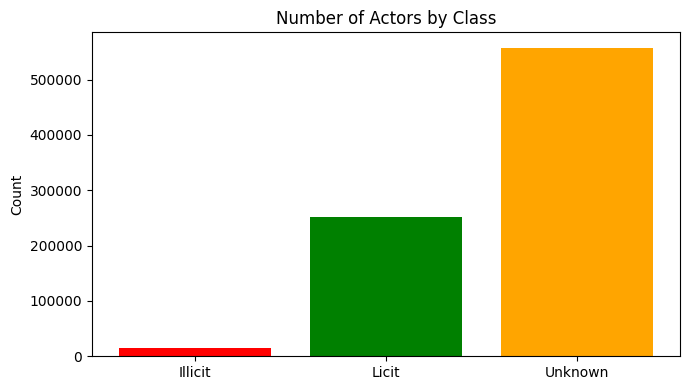

In [ ]:
# Class distribution (full dataset including unknowns)
print("Actor class distribution:")
vc = df_wallets_classes["class"].value_counts().sort_index()
print(vc)
print()
total = len(df_wallets_classes)
for cls, name in [(1, "Illicit"), (2, "Licit"), (3, "Unknown")]:
    n = (df_wallets_classes["class"] == cls).sum()
    print(f"  {name} (class {cls}): {n:,} ({n/total*100:.1f}%)")

actor_by_class = df_wallets_classes.groupby("class").count()
plt.figure(figsize=(7, 4))
plt.bar(["Illicit", "Licit", "Unknown"], actor_by_class["address"].values,
        color=["red", "green", "orange"])
plt.title("Number of Actors by Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [ ]:
# Address count statistics
print("Unique input addresses  :", len(df_AddrTx_edgelist["input_address"].unique()))
print("Unique output addresses :", len(df_TxAddr_edgelist["output_address"].unique()))
print("Total unique addresses  :", len(df_wallets_classes["address"].unique()))


Unique input addresses  : 400212
Unique output addresses : 641043
Total unique addresses  : 822942


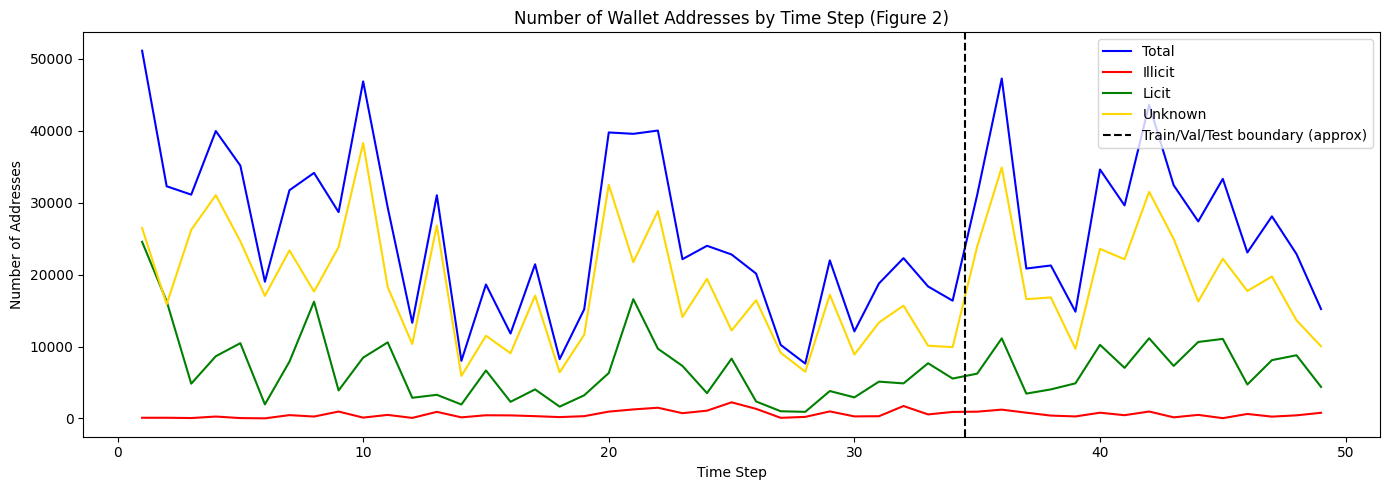

In [ ]:
# Number of actors by time step (Figure 2 in paper)
df_comb = df_wallets_features_classes_combined

total_w   = df_comb.groupby("Time step")["address"].count()
illicit_w = df_comb[df_comb["class"]==1].groupby("Time step")["address"].count()
licit_w   = df_comb[df_comb["class"]==2].groupby("Time step")["address"].count()
unknown_w = df_comb[df_comb["class"]==3].groupby("Time step")["address"].count()

plt.figure(figsize=(14, 5))
plt.plot(total_w.index,   total_w.values,   color="blue",  label="Total")
plt.plot(illicit_w.index, illicit_w.values, color="red",   label="Illicit")
plt.plot(licit_w.index,   licit_w.values,   color="green", label="Licit")
plt.plot(unknown_w.index, unknown_w.values, color="gold",  label="Unknown")
plt.axvline(x=34.5, color="black", linestyle="--", linewidth=1.5,
            label="Train/Val/Test boundary (approx)")
plt.title("Number of Wallet Addresses by Time Step (Figure 2)")
plt.xlabel("Time Step"); plt.ylabel("Number of Addresses")
plt.legend(); plt.tight_layout(); plt.show()


In [ ]:
# Distribution of illicit actors by number of time steps (Table 5)
illicit_1 = df_comb[(df_comb["class"]==1) & (df_comb["num_timesteps_appeared_in"]==1)
    ].drop_duplicates().groupby("Time step").size().rename("Appears in 1 TS")

illicit_2_4 = df_comb[(df_comb["class"]==1) &
    (df_comb["num_timesteps_appeared_in"]>=2) &
    (df_comb["num_timesteps_appeared_in"]<=4)
    ].drop_duplicates().groupby("Time step").size().rename("Appears in 2-4 TS")

illicit_ge5 = df_comb[(df_comb["class"]==1) &
    (df_comb["num_timesteps_appeared_in"]>=5)
    ].drop_duplicates().groupby("Time step").size().rename("Appears in >=5 TS")

df_illicit_dist = pd.concat([illicit_1, illicit_2_4, illicit_ge5],
                              axis=1).fillna(0).astype(int)
print("Distribution of Illicit Actors by Time Steps (Table 5):")
display(df_illicit_dist.T)


Distribution of Illicit Actors by Time Steps (Table 5):


Time step,1,2,3,4,5,6,7,8,9,10,...,40,41,42,43,44,45,46,47,48,49
Appears in 1 TS,68,69,42,186,36,8,233,116,384,26,...,436,168,395,93,277,23,505,193,370,631
Appears in 2-4 TS,5,1,3,15,2,1,28,7,21,11,...,14,8,12,11,6,9,4,11,17,20
Appears in >=5 TS,0,0,0,0,2,2,5,4,3,3,...,3,6,4,1,1,1,0,0,1,1


Illicit actors in >= 5 time steps: 23


,address,num_timesteps_appeared_in
0,12ccSQ7vJZTXgQRkyVwTQGhFKaiqK14uAw,5.0
1,12k7kXAo7JjcHTnoPxpYsYQRVDAZaM4Jfq,10.0
2,141Zu4pHzkYZefE2audb1FU1gRkJ1TNKT6,8.0
3,1DoJZfdNJ6vPTKnGeMaoeasNThpptNP1L1,5.0
4,1FvtWwP3ePJDeR6K7ZePGujUuusUTds8Vy,7.0
5,1GQSnzh9JRgipxC7btKvD3rBS8Zj8SVnAo,15.0
6,1GznpZnvSmnXyWFLHUXAX3oSwARvrnZD1G,5.0
7,1H91HHDt3bEgv3zHk1GqXYnkANJfjHLSZC,6.0
8,1Hmm1KKPDUnwzZjRLSRPtVtTYe2KrEE4U3,10.0
9,1KD6iM6HxWc2UvY9ZK1vZEcQUidmoDxHFB,6.0


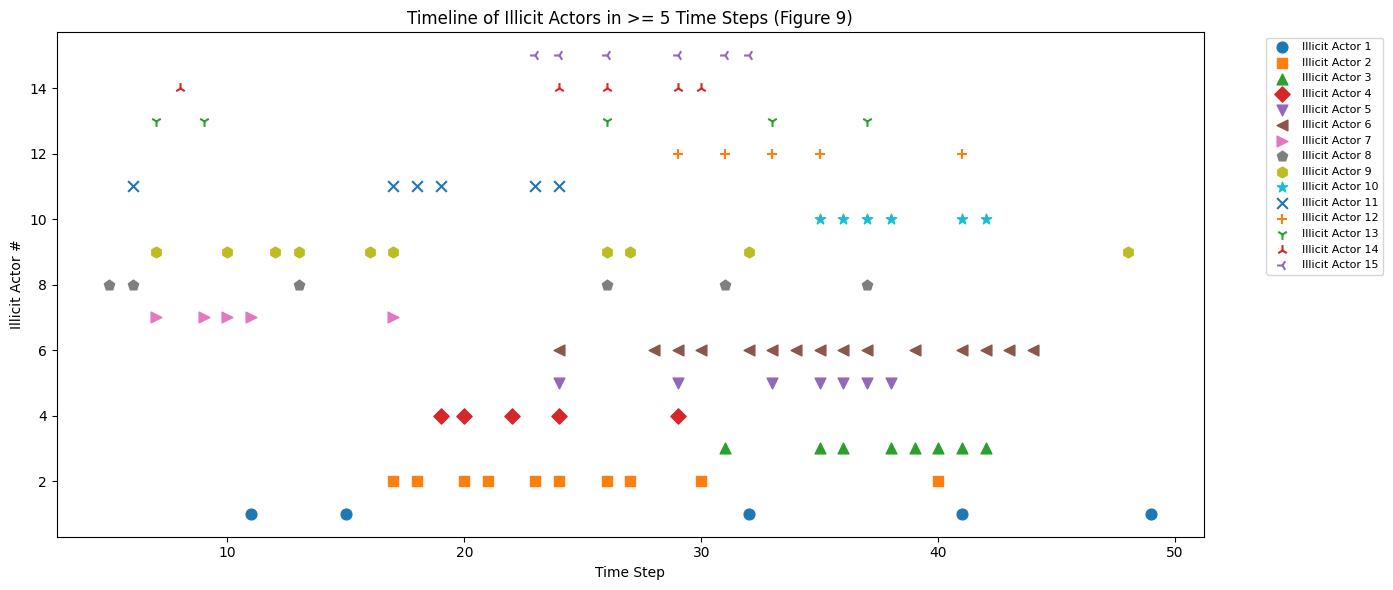

In [ ]:
# Illicit actors in >= 5 time steps + timeline plot (Figure 9)
illicit_actors_ge5 = df_comb[(df_comb["num_timesteps_appeared_in"]>=5) &
                               (df_comb["class"]==1)]
unique_ge5 = illicit_actors_ge5[["address","num_timesteps_appeared_in"]].drop_duplicates()
print(f"Illicit actors in >= 5 time steps: {len(unique_ge5)}")
display(unique_ge5.reset_index(drop=True))

illicit_ge5_addr = unique_ge5["address"].tolist()
fig, ax = plt.subplots(figsize=(14, 6))
markers = ["o","s","^","D","v","<",">","p","h","*","x","+","1","2","3"]
for i, addr in enumerate(illicit_ge5_addr[:15]):
    actor_data = illicit_actors_ge5[illicit_actors_ge5["address"] == addr]
    ax.scatter(actor_data["Time step"].unique(), [i+1]*len(actor_data["Time step"].unique()),
               marker=markers[i % len(markers)], s=60, label=f"Illicit Actor {i+1}")
ax.set_xlabel("Time Step"); ax.set_ylabel("Illicit Actor #")
ax.set_title("Timeline of Illicit Actors in >= 5 Time Steps (Figure 9)")
ax.legend(bbox_to_anchor=(1.05,1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()


In [ ]:
# Bitcoin user entity statistics (Table 6)
print("Computing Bitcoin user entities via address clustering...")

df_AddrTx_temp = df_AddrTx_edgelist.groupby("txId")["input_address"].apply(list)

def to_edges(lst):
    it = iter(lst); last = next(it)
    for current in it:
        yield last, current; last = current

def build_user_graph(lst_of_lists):
    G = nx.Graph()
    for part in lst_of_lists:
        G.add_nodes_from(part); G.add_edges_from(to_edges(part))
    return G

G_users = build_user_graph(df_AddrTx_temp)
all_components = list(nx.connected_components(G_users))
list_components = [len(c) for c in all_components]
num_components  = len(all_components)

print(f"\n  # Users                      : {num_components:,}")
print(f"  Addresses/User (min/med/mean/max): {min(list_components)} / "
      f"{median(list_components)} / {mean(list_components):.2f} / {max(list_components):,}")
pct_1_10  = sum(1 for x in list_components if 1<=x<=10)   / num_components*100
pct_11_1k = sum(1 for x in list_components if 11<=x<=1000) / num_components*100
pct_gt1k  = sum(1 for x in list_components if x>1000)      / num_components*100
print(f"  % Users w/ 1-10 addr   : {pct_1_10:.2f}%")
print(f"  % Users w/ 11-1K addr  : {pct_11_1k:.2f}%")
print(f"  % Users w/ 1K+ addr    : {pct_gt1k:.2f}%")
del G_users


Computing Bitcoin user entities via address clustering...

  # Users                      : 146,783
  Addresses/User (min/med/mean/max): 1 / 1 / 2.73 / 14,885
  % Users w/ 1-10 addr   : 98.72%
  % Users w/ 11-1K addr  : 1.26%
  % Users w/ 1K+ addr    : 0.02%


---
## Section 5: Graph Visualization

### 5.1 Address-Transaction Graph (Figure 5)


### 5.2 Actor Interaction Graph (Figure 4)

---
## Section 6: Feature Correlation Analysis (Figure 8 in paper)

Good features show clear class separation over time. Bad features show none.


=== GOOD features (high class separation) ===


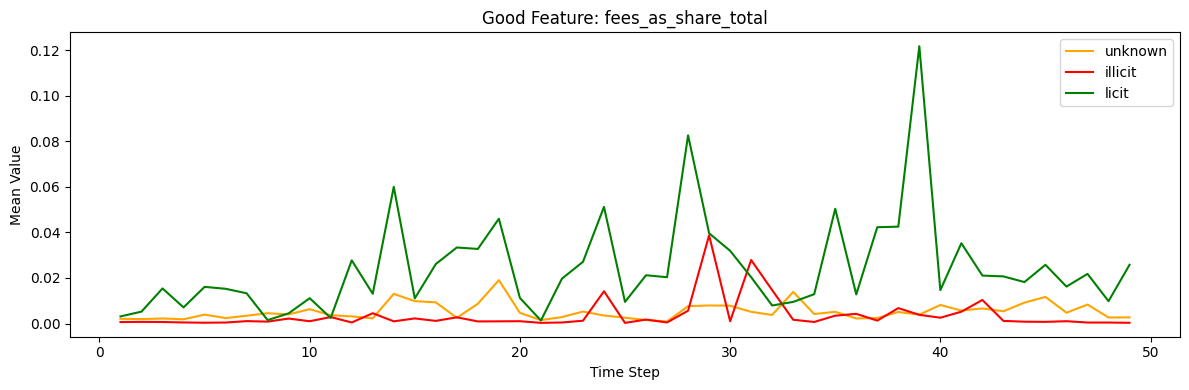

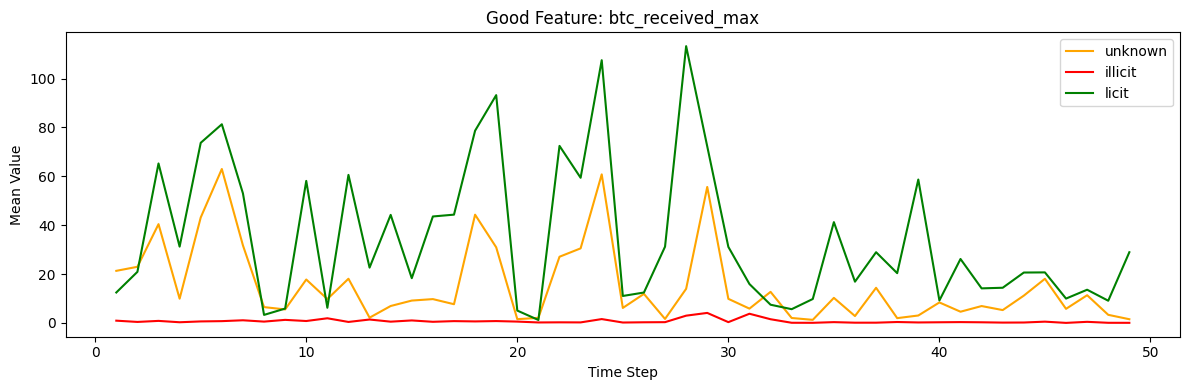

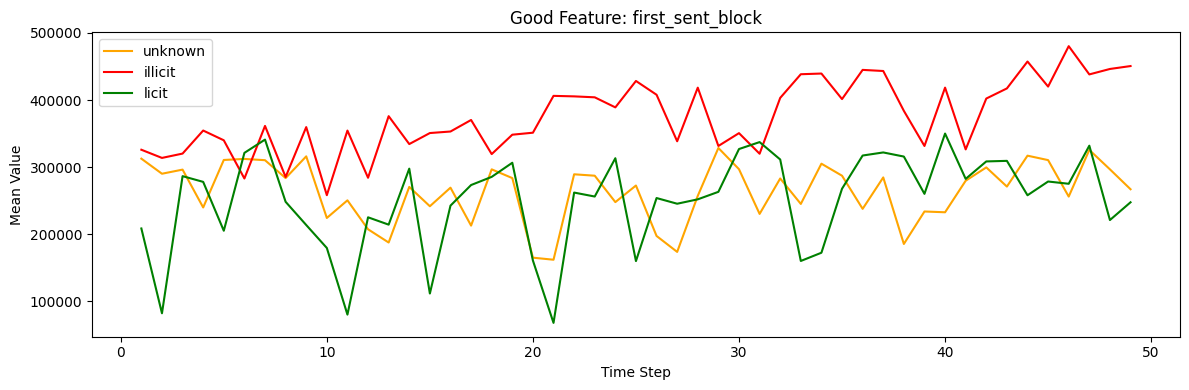

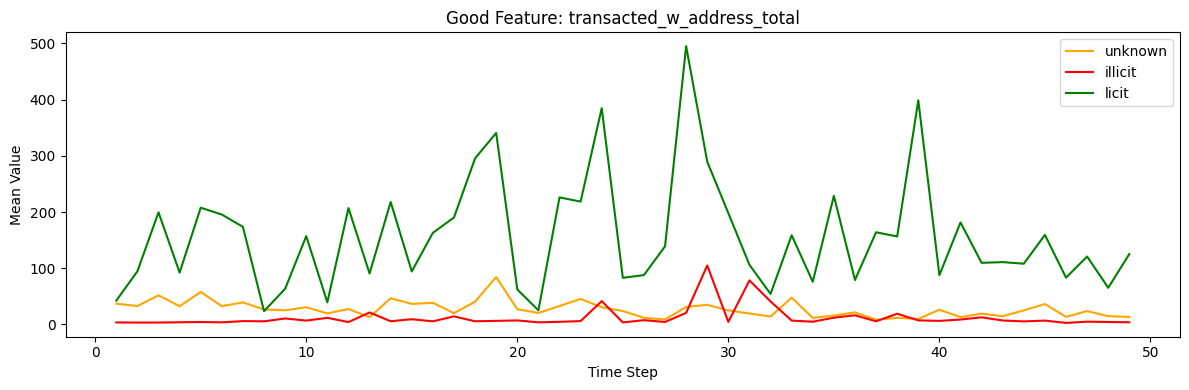


=== BAD features (low class separation) ===


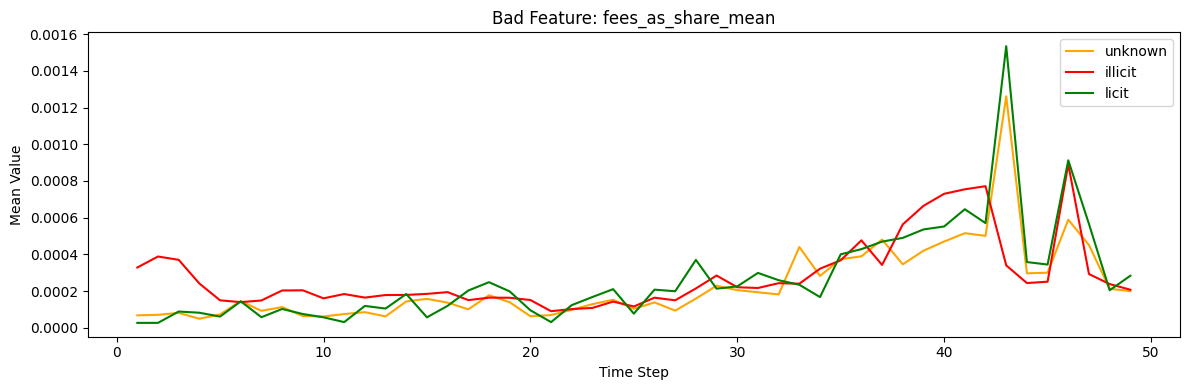

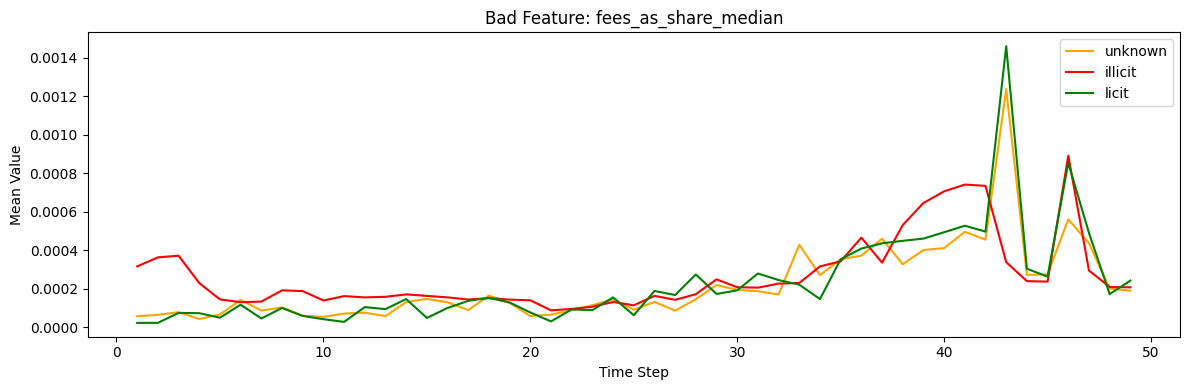

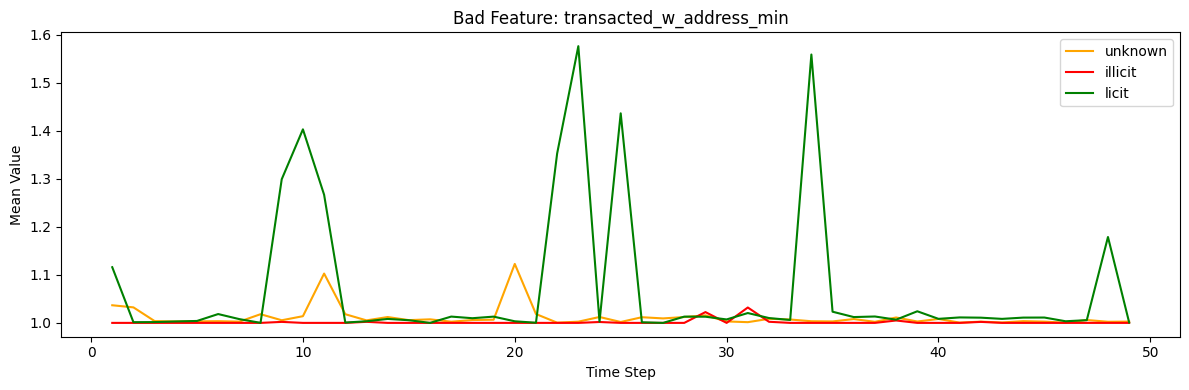

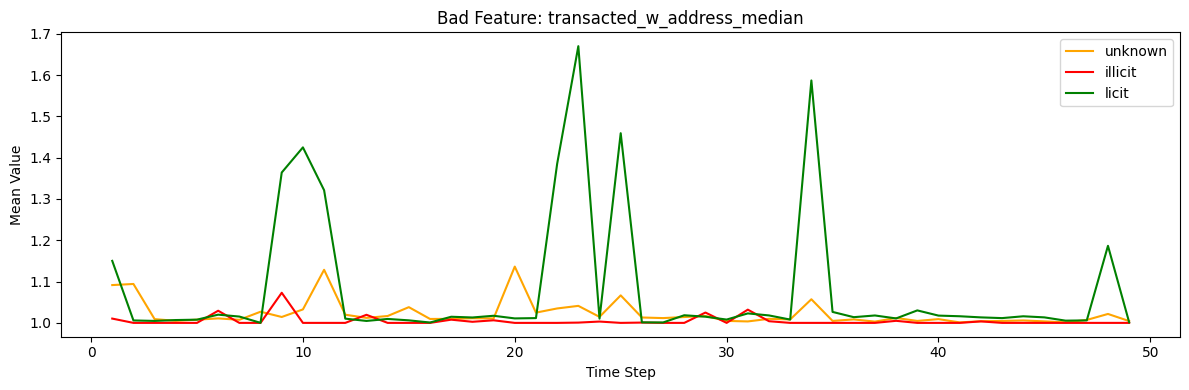

In [ ]:
df_feat_corr = df_wallets_features_classes_combined.copy()
df_feat_corr["class_label"] = df_feat_corr["class"].map(
    {1:"illicit",2:"licit",3:"unknown"})

good_features = ["fees_as_share_total","btc_received_max",
                 "first_sent_block","transacted_w_address_total"]
bad_features  = ["fees_as_share_mean","fees_as_share_median",
                 "transacted_w_address_min","transacted_w_address_median"]

def plot_feature_trends(features, title_prefix):
    for feat in features:
        if feat not in df_feat_corr.columns:
            matches = [c for c in df_feat_corr.columns
                       if feat.replace("_","") in c.replace("_","").lower()]
            feat = matches[0] if matches else None
            if feat is None: continue
        grouped = df_feat_corr.groupby(["Time step","class_label"])[feat].mean().reset_index()
        plt.figure(figsize=(12,4))
        for label, color in [("unknown","orange"),("illicit","red"),("licit","green")]:
            sub = grouped[grouped["class_label"]==label]
            if not sub.empty:
                plt.plot(sub["Time step"], sub[feat], color=color, label=label)
        plt.title(f"{title_prefix}: {feat}")
        plt.xlabel("Time Step"); plt.ylabel("Mean Value")
        plt.legend(); plt.tight_layout(); plt.show()

print("=== GOOD features (high class separation) ===")
plot_feature_trends(good_features, "Good Feature")
print("\n=== BAD features (low class separation) ===")
plot_feature_trends(bad_features, "Bad Feature")


---
## Section 7: Preprocessing — Time-Aware Split · Scaling · Class Weights

### Key improvements over the original pipeline:
1. **Split before scale** — eliminates data leakage from the scaler seeing test/val data
2. **Three-way temporal split** — train / validation / test based on time step order
3. **Class weights** — computed on training data only, passed to each model
4. Validation set used for feature importance (Section 10) and model selection
5. Test set touched only once for final reported metrics


In [ ]:
# ── Step 1: Drop Time step, deduplicate, remove unknowns ─────────────────────
df_clf = df_wallets_features_classes_combined.copy()
df_clf = df_clf.drop(columns=["Time step"]).drop_duplicates()

# Keep only labelled (illicit=1, licit=2); drop unknown=3
df_clf = df_clf[df_clf["class"] != 3].copy().reset_index(drop=True)

print(f"Shape after dedup + drop unknowns: {df_clf.shape}")
print(f"  Illicit (class 1): {(df_clf['class']==1).sum():,}")
print(f"  Licit   (class 2): {(df_clf['class']==2).sum():,}")


Shape after dedup + drop unknowns: (265354, 57)
  Illicit (class 1): 14,266
  Licit   (class 2): 251,088


In [ ]:
# ── Step 2: Binary labels — 0=licit, 1=illicit ───────────────────────────────
y_all = df_clf["class"].apply(lambda x: 0 if x == 2 else 1)
X_all = df_clf.drop(columns=["address","class"])

print(f"Total labelled samples : {len(y_all):,}")
print(f"  Illicit (1)          : {y_all.sum():,} ({y_all.mean()*100:.1f}%)")
print(f"  Licit   (0)          : {(y_all==0).sum():,} ({(y_all==0).mean()*100:.1f}%)")


Total labelled samples : 265,354
  Illicit (1)          : 14,266 (5.4%)
  Licit   (0)          : 251,088 (94.6%)


In [ ]:
# ── Step 3: three-way split──────────────────────────
# 60% train | 20% validation | 20% test

# First cut: 80% temp | 20% test
X_temp, X_test_raw, y_temp, y_test = train_test_split(
    X_all, y_all, test_size=0.20, shuffle=True)

# Second cut: 75% of temp = train (60% overall) | 25% of temp = val (20% overall)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, shuffle=True, random_state=None)

print(f"Train set : {X_train_raw.shape[0]:,} samples  "
      f"(Illicit: {y_train.sum():,} = {y_train.mean()*100:.1f}%)")
print(f"Val set   : {X_val_raw.shape[0]:,} samples  "
      f"(Illicit: {y_val.sum():,} = {y_val.mean()*100:.1f}%)")
print(f"Test set  : {X_test_raw.shape[0]:,} samples  "
      f"(Illicit: {y_test.sum():,} = {y_test.mean()*100:.1f}%)")
print(f"Features  : {X_train_raw.shape[1]}")


Train set : 159,212 samples  (Illicit: 8,680 = 5.5%)
Val set   : 53,071 samples  (Illicit: 2,771 = 5.2%)
Test set  : 53,071 samples  (Illicit: 2,815 = 5.3%)
Features  : 55


In [ ]:
# ── Step 4: Scale AFTER split — fit on train only ─────────────────────────────
# Using train min/max to transform val and test avoids leakage
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)   # fit + transform on train
X_val   = scaler.transform(X_val_raw)          # transform only
X_test  = scaler.transform(X_test_raw)         # transform only

# Keep column names for feature importance later
feature_names = X_all.columns.tolist()

print("Scaling complete.")
print(f"  Train range after scaling: [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"  Val   range after scaling: [{X_val.min():.3f}, {X_val.max():.3f}]")
print(f"  Test  range after scaling: [{X_test.min():.3f}, {X_test.max():.3f}]")
print("  Note: val/test may slightly exceed [0,1] if they contain values")
print("  outside the training range — this is expected and correct behaviour.")


Scaling complete.
  Train range after scaling: [0.000, 1.000]
  Val   range after scaling: [0.000, 3.130]
  Test  range after scaling: [0.000, 1.468]
  Note: val/test may slightly exceed [0,1] if they contain values
  outside the training range — this is expected and correct behaviour.


In [ ]:
# ── Step 5: Compute class weights from training set only ──────────────────────
# class_weight='balanced' computes: n_samples / (n_classes * np.bincount(y))
# This is passed directly to LR and RF.
# For MLP, compute_sample_weight produces per-sample weights.
# For XGBoost, scale_pos_weight = count(negative) / count(positive).

from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
cw = compute_class_weight("balanced", classes=classes, y=y_train.values)
class_weight_dict = {0: cw[0], 1: cw[1]}

# Sample weights for MLP
sample_weights_train = compute_sample_weight("balanced", y=y_train.values)

# XGBoost scale_pos_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
xgb_scale_pos = neg_count / pos_count

print(f"Class weight dict          : {class_weight_dict}")
print(f"XGBoost scale_pos_weight   : {xgb_scale_pos:.2f}")
print(f"Train imbalance ratio      : {neg_count/pos_count:.1f}:1 (licit:illicit)")


Class weight dict          : {0: np.float64(0.5288310791061037), 1: np.float64(9.171198156682028)}
XGBoost scale_pos_weight   : 17.34
Train imbalance ratio      : 17.3:1 (licit:illicit)


---
## Section 8: ML Classification

Training individual classifiers on the training set,
evaluating on the **validation set**. Final test-set evaluation at the end.


In [ ]:
# ── Evaluation helper ────────────────────────────────────────────────────────
def evaluate(name, y_true, y_pred, results_list, split="val"):
    """Compute Precision, Recall, F1, Micro-F1, MCC, and Accuracy for the illicit class."""
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, zero_division=0)
    micro_f1 = f1_score(y_true, y_pred, average="micro")
    mcc = matthews_corrcoef(y_true, y_pred)
    accuracy = (y_true == y_pred).mean() # Calculate accuracy
    row = {
        "Model": name, "Split": split,
        "Precision": round(prec[1],3), "Recall": round(rec[1],3),
        "F1": round(f1[1],3), "Micro-F1": round(micro_f1,3),
        "MCC": round(mcc,3), "Accuracy": round(accuracy,3) # Add Accuracy to the row
    }
    results_list.append(row)
    print(f"  {name:<45} Prec={prec[1]:.3f}  Rec={rec[1]:.3f}  " # Update print statement
          f"F1={f1[1]:.3f}  MCC={mcc:.3f}  Acc={accuracy:.3f}  [{split}]")
    return row

results = []

### 8.1 Individual Classifiers

In [ ]:
print("=" * 105)
print("INDIVIDUAL CLASSIFIERS — evaluated on VALIDATION SET")
print("=" * 105)

# ── Logistic Regression ───────────────────────────────────────────────────────
cLR = LogisticRegression(max_iter=1000, class_weight="balanced")
cLR.fit(X_train, y_train.values)
evaluate("Logistic Regression (LR)", y_val.values,
         cLR.predict(X_val), results)


INDIVIDUAL CLASSIFIERS — evaluated on VALIDATION SET
  Logistic Regression (LR)                      Prec=0.211  Rec=0.687  F1=0.323  MCC=0.323  Acc=0.849  [val]


{'Model': 'Logistic Regression (LR)',
 'Split': 'val',
 'Precision': np.float64(0.211),
 'Recall': np.float64(0.687),
 'F1': np.float64(0.323),
 'Micro-F1': 0.849,
 'MCC': np.float64(0.323),
 'Accuracy': np.float64(0.849)}

In [ ]:
# ── Random Forest ────────────────────────────────────────────────────────────
cRF = RandomForestClassifier(n_estimators=50, random_state=42,
                              class_weight="balanced")
cRF.fit(X_train, y_train.values)
evaluate("Random Forest (RF, 50 trees)", y_val.values,
         cRF.predict(X_val), results)


  Random Forest (RF, 50 trees)                  Prec=0.958  Rec=0.776  F1=0.857  MCC=0.856  Acc=0.987  [val]


{'Model': 'Random Forest (RF, 50 trees)',
 'Split': 'val',
 'Precision': np.float64(0.958),
 'Recall': np.float64(0.776),
 'F1': np.float64(0.857),
 'Micro-F1': 0.987,
 'MCC': np.float64(0.856),
 'Accuracy': np.float64(0.987)}

In [ ]:
# ── MLP ──────────────────────────────────────────────────────────────────────
# MLP does not accept class_weight; use sample_weight in fit() instead
# NOTE: sklearn.neural_network.MLPClassifier does not support sample_weight directly in fit().
# To handle class imbalance for MLP, consider using resampling techniques like SMOTE
# or RandomOverSampler on the training data before fitting the model.
cMLP = MLPClassifier(hidden_layer_sizes=(50,), solver="adam",
                     learning_rate_init=0.001, max_iter=500, random_state=42)
# Removed sample_weight as MLPClassifier.fit() does not accept it.
cMLP.fit(X_train, y_train.values)
evaluate("Multilayer Perceptron (MLP)", y_val.values,
         cMLP.predict(X_val), results)

  Multilayer Perceptron (MLP)                   Prec=0.777  Rec=0.391  F1=0.520  MCC=0.535  Acc=0.962  [val]


{'Model': 'Multilayer Perceptron (MLP)',
 'Split': 'val',
 'Precision': np.float64(0.777),
 'Recall': np.float64(0.391),
 'F1': np.float64(0.52),
 'Micro-F1': 0.962,
 'MCC': np.float64(0.535),
 'Accuracy': np.float64(0.962)}

In [ ]:
# ── XGBoost ──────────────────────────────────────────────────────────────────
# Using binary:logistic (correct for 2-class) + scale_pos_weight for imbalance
cXGB = xgb.XGBClassifier(
    objective="binary:logistic",
    scale_pos_weight=xgb_scale_pos,
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)
cXGB.fit(X_train, y_train.values)
evaluate("XGBoost (XGB)", y_val.values,
         cXGB.predict(X_val), results)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[04:37:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




  XGBoost (XGB)                                 Prec=0.660  Rec=0.946  F1=0.777  MCC=0.777  Acc=0.972  [val]


{'Model': 'XGBoost (XGB)',
 'Split': 'val',
 'Precision': np.float64(0.66),
 'Recall': np.float64(0.946),
 'F1': np.float64(0.777),
 'Micro-F1': 0.972,
 'MCC': np.float64(0.777),
 'Accuracy': np.float64(0.972)}

---
## Section 9: Cross-Validation & Hyperparameter Tuning

Stratified K-Fold


In [ ]:
from sklearn.model_selection import StratifiedKFold

# ── TimeSeriesSplit setup ─────────────────────────────────────────────────────
# We run CV
X_cv = X_temp.values
y_cv = y_temp.values

N_SPLITS = 5
tscv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42) # Changed to StratifiedKFold

cv_results = {m: {"precision":[],"recall":[],"f1":[],"mcc":[],"accuracy":[]} # Added accuracy to cv_results
              for m in ["LR","RF","MLP","XGB"]}

print(f"Running Stratified K-Fold CV with {N_SPLITS} folds...") # Updated print statement
print("=" * 80)

for fold, (train_idx, test_idx) in enumerate(
        tqdm(list(tscv.split(X_cv, y_cv)), desc="CV Folds", unit="fold"), 1):
    X_f_tr, X_f_te = X_cv[train_idx], X_cv[test_idx]
    y_f_tr, y_f_te = y_cv[train_idx], y_cv[test_idx]

    # Scale within fold — fit only on fold's train
    sc = MinMaxScaler()
    X_f_tr = sc.fit_transform(X_f_tr)
    X_f_te = sc.transform(X_f_te)

    # Skip folds with no illicit in test (should be less likely with StratifiedKFold)
    if y_f_te.sum() == 0:
        print(f"  Fold {fold}: skipped (no illicit in test split)")
        continue

    # Class weights for this fold
    sw = compute_sample_weight("balanced", y=y_f_tr)
    neg_f = (y_f_tr==0).sum(); pos_f = (y_f_tr==1).sum()
    spos_f = neg_f / pos_f

    print(f"\nFold {fold}  train={len(y_f_tr):,}  test={len(y_f_te):,}  "
          f"illicit_test={y_f_te.sum()}")

    # ── Models ────────────────────────────────────────────────────────────────
    preds = {}

    lr_f = LogisticRegression(max_iter=1000, class_weight="balanced")
    lr_f.fit(X_f_tr, y_f_tr); preds["LR"] = lr_f.predict(X_f_te)

    rf_f = RandomForestClassifier(n_estimators=50, random_state=42,
                                   class_weight="balanced")
    rf_f.fit(X_f_tr, y_f_tr); preds["RF"] = rf_f.predict(X_f_te)

    mlp_f = MLPClassifier(hidden_layer_sizes=(50,), solver="adam",
                          learning_rate_init=0.001, max_iter=500, random_state=42)
    mlp_f.fit(X_f_tr, y_f_tr); preds["MLP"] = mlp_f.predict(X_f_te)

    xgb_f = xgb.XGBClassifier(objective="binary:logistic", scale_pos_weight=spos_f,
                                random_state=42, eval_metric="logloss") # Removed use_label_encoder=False
    xgb_f.fit(X_f_tr, y_f_tr); preds["XGB"] = xgb_f.predict(X_f_te)

    for mname, ypred in preds.items():
        pr, rec, f1_, _ = precision_recall_fscore_support(
            y_f_te, ypred, zero_division=0)
        mcc_ = matthews_corrcoef(y_f_te, ypred)
        accuracy_ = (y_f_te == ypred).mean() # Calculate accuracy for the fold
        cv_results[mname]["precision"].append(pr[1])
        cv_results[mname]["recall"].append(rec[1])
        cv_results[mname]["f1"].append(f1_[1])
        cv_results[mname]["mcc"].append(mcc_)
        cv_results[mname]["accuracy"].append(accuracy_) # Append accuracy
        print(f"  {mname:<5}  Prec={pr[1]:.3f}  Rec={rec[1]:.3f}  "
              f"F1={f1_[1]:.3f}  MCC={mcc_:.3f}  Acc={accuracy_:.3f}") # Updated print statement


Running Stratified K-Fold CV with 5 folds...


CV Folds:   0%|          | 0/5 [00:00<?, ?fold/s]


Fold 1  train=169,826  test=42,457  illicit_test=2290
  LR     Prec=0.220  Rec=0.712  F1=0.336  MCC=0.338  Acc=0.848
  RF     Prec=0.967  Rec=0.771  F1=0.858  MCC=0.857  Acc=0.986
  MLP    Prec=0.879  Rec=0.376  F1=0.526  MCC=0.561  Acc=0.964
  XGB    Prec=0.679  Rec=0.935  F1=0.787  MCC=0.784  Acc=0.973

Fold 2  train=169,826  test=42,457  illicit_test=2290
  LR     Prec=0.224  Rec=0.706  F1=0.340  MCC=0.341  Acc=0.852
  RF     Prec=0.956  Rec=0.768  F1=0.852  MCC=0.850  Acc=0.986
  MLP    Prec=0.855  Rec=0.336  F1=0.483  MCC=0.522  Acc=0.961
  XGB    Prec=0.692  Rec=0.945  F1=0.799  MCC=0.796  Acc=0.974

Fold 3  train=169,826  test=42,457  illicit_test=2291
  LR     Prec=0.225  Rec=0.677  F1=0.338  MCC=0.334  Acc=0.857
  RF     Prec=0.963  Rec=0.790  F1=0.868  MCC=0.866  Acc=0.987
  MLP    Prec=0.879  Rec=0.348  F1=0.498  MCC=0.539  Acc=0.962
  XGB    Prec=0.674  Rec=0.951  F1=0.789  MCC=0.788  Acc=0.972

Fold 4  train=169,827  test=42,456  illicit_test=2290
  LR     Prec=0.219  Rec

In [ ]:
# ── CV Summary table — mean ± std ─────────────────────────────────────────────
print("\n" + "=" * 80)
print("CV Summary (mean ± std across folds)")
print("=" * 80)

cv_summary = []
for mname, metrics in cv_results.items():
    row = {"Model": mname}
    for metric, vals in metrics.items():
        if vals:
            row[metric] = f"{np.mean(vals):.3f} \u00b1 {np.std(vals):.3f}"
    cv_summary.append(row)

df_cv = pd.DataFrame(cv_summary).set_index("Model")
df_cv.columns = ["Precision (μ±σ)","Recall (μ±σ)","F1 (μ±σ)","MCC (μ±σ)","Accuracy (μ±σ)"] # Added Accuracy to columns
display(df_cv)


CV Summary (mean ± std across folds)


,Precision (μ±σ),Recall (μ±σ),F1 (μ±σ),MCC (μ±σ),Accuracy (μ±σ)
Model,,,,,
LR,0.221 ± 0.003,0.708 ± 0.017,0.337 ± 0.002,0.338 ± 0.003,0.850 ± 0.004
RF,0.961 ± 0.004,0.780 ± 0.009,0.861 ± 0.006,0.859 ± 0.006,0.986 ± 0.001
MLP,0.837 ± 0.045,0.369 ± 0.023,0.510 ± 0.017,0.540 ± 0.013,0.962 ± 0.001
XGB,0.675 ± 0.015,0.944 ± 0.006,0.787 ± 0.009,0.785 ± 0.009,0.972 ± 0.002


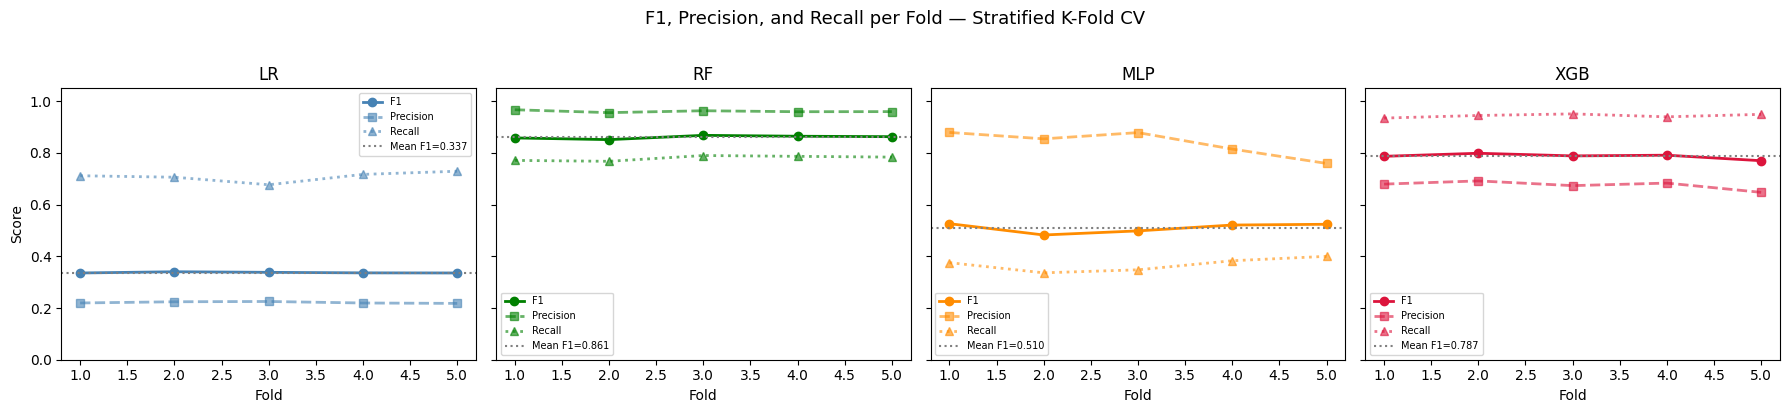

In [ ]:
# ── Fold-by-fold F1 and Precision visualisation ─────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
colors = {"LR":"steelblue","RF":"green","MLP":"darkorange","XGB":"crimson"}

for ax, (mname, metrics) in zip(axes, cv_results.items()):
    folds = range(1, len(metrics["f1"])+1)
    ax.plot(folds, metrics["f1"],    marker="o", color=colors[mname],
            linewidth=2, label="F1")
    ax.plot(folds, metrics["precision"],marker="s", color=colors[mname],
            linewidth=2, linestyle="--", alpha=0.6, label="Precision")
    ax.plot(folds, metrics["recall"],marker="^", color=colors[mname],
            linewidth=2, linestyle=":", alpha=0.6, label="Recall") # Added Recall line
    ax.axhline(np.mean(metrics["f1"]), color="gray", linestyle=":",
               label=f"Mean F1={np.mean(metrics['f1']):.3f}")
    ax.set_title(mname, fontsize=12)
    ax.set_xlabel("Fold"); ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7)
axes[0].set_ylabel("Score")
plt.suptitle("F1, Precision, and Recall per Fold — Stratified K-Fold CV", y=1.02, fontsize=13) # Updated title
plt.tight_layout()
plt.show()

In [ ]:
# ── Hyperparameter tuning via CV — RF n_estimators example ──────────────────
# Demonstrate how CV can guide hyperparameter choices
# We test RF with different n_estimators and pick the best by mean F1

print("Hyperparameter search: RF n_estimators via Stratified K-Fold CV") # Updated print statement
print("-" * 60)

n_est_options = [10, 25, 50, 100, 200]
hp_results = []

for n_est in tqdm(n_est_options, desc="RF n_estimators", unit="config"):
    fold_f1_scores = []
    for train_idx, test_idx in tqdm(list(tscv.split(X_cv, y_cv)), # Ensure tscv.split uses y_cv for stratification
                                    desc=f"  n_est={n_est} folds",
                                    leave=False, unit="fold"):
        X_f_tr, X_f_te = X_cv[train_idx], X_cv[test_idx]
        y_f_tr, y_f_te = y_cv[train_idx], y_cv[test_idx]
        if y_f_te.sum() == 0: continue
        sc = MinMaxScaler()
        X_f_tr = sc.fit_transform(X_f_tr); X_f_te = sc.transform(X_f_te)
        rf_hp = RandomForestClassifier(n_estimators=n_est, random_state=42,
                                        class_weight="balanced")
        rf_hp.fit(X_f_tr, y_f_tr)
        y_pred_f_te = rf_hp.predict(X_f_te)
        f1_illicit = f1_score(y_f_te, y_pred_f_te, average='binary', pos_label=1, zero_division=0)
        fold_f1_scores.append(f1_illicit)
    mean_f1 = np.mean(fold_f1_scores)
    std_f1  = np.std(fold_f1_scores)
    hp_results.append({"n_estimators": n_est,
                        "mean_F1": round(mean_f1,3),
                        "std_F1":  round(std_f1,3)})
    print(f"  n_estimators={n_est:<4}  mean F1={mean_f1:.3f} \u00b1 {std_f1:.3f}")

df_hp = pd.DataFrame(hp_results)
best_n = int(df_hp.loc[df_hp["mean_F1"].idxmax(), "n_estimators"])
print(f"\nBest n_estimators = {best_n}  (mean F1 = "
      f"{df_hp['mean_F1'].max():.3f})")
display(df_hp)

Hyperparameter search: RF n_estimators via Stratified K-Fold CV
------------------------------------------------------------


RF n_estimators:   0%|          | 0/5 [00:00<?, ?config/s]

  n_est=10 folds:   0%|          | 0/5 [00:00<?, ?fold/s]

  n_estimators=10    mean F1=0.850 ± 0.008


  n_est=25 folds:   0%|          | 0/5 [00:00<?, ?fold/s]

...

  n_est=100 folds:   0%|          | 0/5 [00:00<?, ?fold/s]

  n_estimators=100   mean F1=0.863 ± 0.007


  n_est=200 folds:   0%|          | 0/5 [00:00<?, ?fold/s]

  n_estimators=200   mean F1=0.864 ± 0.007

Best n_estimators = 200  (mean F1 = 0.864)


,n_estimators,mean_F1,std_F1
0,10,0.850,0.008
1,25,0.861,0.007
2,50,0.861,0.006
3,100,0.863,0.007
4,200,0.864,0.007


In [ ]:
print("Hyperparameter search: XGBoost n_estimators and max_depth via Stratified K-Fold CV")
print("-" * 80)

# Define hyperparameter options to test for XGBoost
n_est_options_xgb = [50, 100, 150]
max_depth_options = [3, 5, 7]
hp_results_xgb = []

# Loop through each combination of n_estimators and max_depth
for n_est_xgb in tqdm(n_est_options_xgb, desc="XGB n_estimators", unit="n_est"):
    for md in tqdm(max_depth_options, desc=f"  max_depth for n_est={n_est_xgb}", leave=False, unit="md"):
        fold_f1_scores_xgb = []
        # Iterate through cross-validation folds
        for train_idx, test_idx in tscv.split(X_cv, y_cv):
            X_f_tr, X_f_te = X_cv[train_idx], X_cv[test_idx]
            y_f_tr, y_f_te = y_cv[train_idx], y_cv[test_idx]

            # Skip folds with no illicit in test (should be less likely with StratifiedKFold)
            if y_f_te.sum() == 0: continue

            # Scale within fold — fit only on fold's train
            sc = MinMaxScaler()
            X_f_tr = sc.fit_transform(X_f_tr)
            X_f_te = sc.transform(X_f_te)

            # Calculate scale_pos_weight for this fold's training data
            neg_f = (y_f_tr == 0).sum()
            pos_f = (y_f_tr == 1).sum()
            xgb_scale_pos_f = neg_f / pos_f

            # Initialize and train XGBoost with current hyperparameters
            xgb_hp = xgb.XGBClassifier(
                objective="binary:logistic",
                n_estimators=n_est_xgb,
                max_depth=md,
                scale_pos_weight=xgb_scale_pos_f,
                random_state=42,
                eval_metric="logloss"
            )
            xgb_hp.fit(X_f_tr, y_f_tr)

            # Predict and calculate F1-score for the illicit class
            y_pred_f_te = xgb_hp.predict(X_f_te)
            f1_illicit_xgb = f1_score(y_f_te, y_pred_f_te, average='binary', pos_label=1, zero_division=0)
            fold_f1_scores_xgb.append(f1_illicit_xgb)

        # Calculate mean and std of F1-scores across folds for the current hyperparameter combination
        mean_f1_xgb = np.mean(fold_f1_scores_xgb)
        std_f1_xgb  = np.std(fold_f1_scores_xgb)
        hp_results_xgb.append({"n_estimators": n_est_xgb, "max_depth": md,
                                "mean_F1": round(mean_f1_xgb,3),
                                "std_F1":  round(std_f1_xgb,3)})
        print(f"  n_estimators={n_est_xgb:<4}, max_depth={md:<2}  mean F1={mean_f1_xgb:.3f} \u00b1 {std_f1_xgb:.3f}")

df_hp_xgb = pd.DataFrame(hp_results_xgb)
best_n_xgb = int(df_hp_xgb.loc[df_hp_xgb["mean_F1"].idxmax(), "n_estimators"])
best_max_depth_xgb = int(df_hp_xgb.loc[df_hp_xgb["mean_F1"].idxmax(), "max_depth"])

print(f"\nBest XGBoost hyperparameters: n_estimators = {best_n_xgb}, max_depth = {best_max_depth_xgb}  (mean F1 = "
      f"{df_hp_xgb['mean_F1'].max():.3f})")
display(df_hp_xgb)

# Update the best_n variable for XGBoost to be used later in feature-refined models
best_n_xgb_tuned = best_n_xgb # Use a new variable to avoid conflict with RF's best_n

Hyperparameter search: XGBoost n_estimators and max_depth via Stratified K-Fold CV
--------------------------------------------------------------------------------


XGB n_estimators:   0%|          | 0/3 [00:00<?, ?n_est/s]

  max_depth for n_est=50:   0%|          | 0/3 [00:00<?, ?md/s]

  n_estimators=50  , max_depth=3   mean F1=0.537 ± 0.005
  n_estimators=50  , max_depth=5   mean F1=0.649 ± 0.011
  n_estimators=50  , max_depth=7   mean F1=0.750 ± 0.009


  max_depth for n_est=100:   0%|          | 0/3 [00:00<?, ?md/s]

  n_estimators=100 , max_depth=3   mean F1=0.592 ± 0.004
  n_estimators=100 , max_depth=5   mean F1=0.728 ± 0.007
  n_estimators=100 , max_depth=7   mean F1=0.829 ± 0.003


  max_depth for n_est=150:   0%|          | 0/3 [00:00<?, ?md/s]

  n_estimators=150 , max_depth=3   mean F1=0.630 ± 0.004
  n_estimators=150 , max_depth=5   mean F1=0.776 ± 0.007
  n_estimators=150 , max_depth=7   mean F1=0.865 ± 0.006

Best XGBoost hyperparameters: n_estimators = 150, max_depth = 7  (mean F1 = 0.865)


,n_estimators,max_depth,mean_F1,std_F1
0,50,3,0.537,0.005
1,50,5,0.649,0.011
2,50,7,0.750,0.009
3,100,3,0.592,0.004
4,100,5,0.728,0.007
5,100,7,0.829,0.003
6,150,3,0.630,0.004
7,150,5,0.776,0.007
8,150,7,0.865,0.006


Generating Overfitting Curves (F1-score) on Train vs Val (Before Feature Selection)...

  LR    - Train F1: 0.334, Val F1: 0.323
  RF    - Train F1: 0.999, Val F1: 0.857
  MLP   - Train F1: 0.531, Val F1: 0.520
  XGB   - Train F1: 0.832, Val F1: 0.777


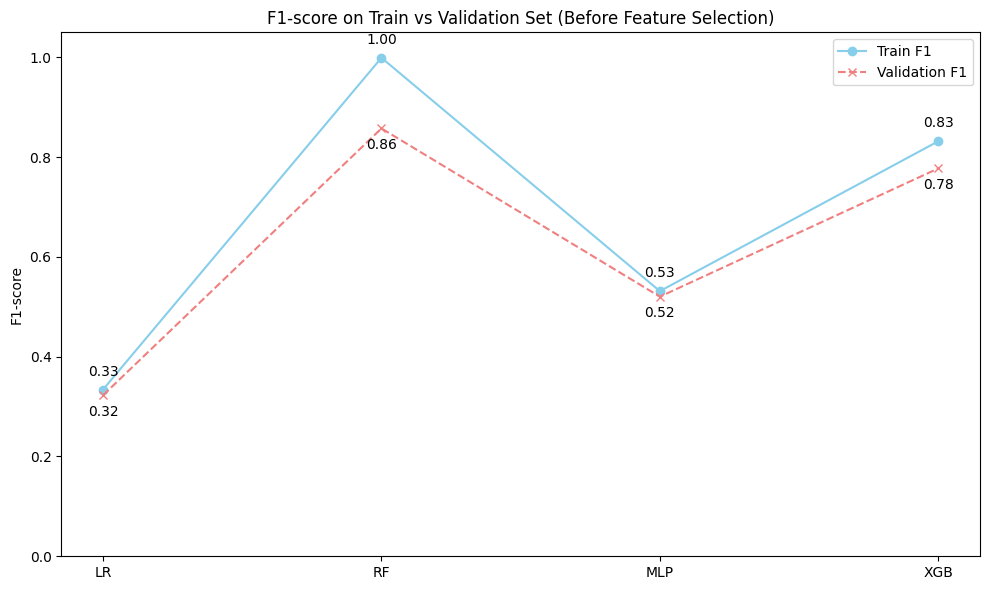

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

print("Generating Overfitting Curves (F1-score) on Train vs Val (Before Feature Selection)...\n")

models = {
    "LR": cLR,
    "RF": cRF,
    "MLP": cMLP,
    "XGB": cXGB
}

model_names = list(models.keys())
train_f1_scores = []
val_f1_scores = []

for name, model in models.items():
    # Predict on training set
    y_pred_train = model.predict(X_train)
    f1_train = f1_score(y_train, y_pred_train, average='binary', pos_label=1, zero_division=0)
    train_f1_scores.append(f1_train)

    # Predict on validation set
    y_pred_val = model.predict(X_val)
    f1_val = f1_score(y_val, y_pred_val, average='binary', pos_label=1, zero_division=0)
    val_f1_scores.append(f1_val)

    print(f"  {name:<5} - Train F1: {f1_train:.3f}, Val F1: {f1_val:.3f}")

x = range(len(model_names))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, train_f1_scores, marker='o', linestyle='-', color='skyblue', label='Train F1')
ax.plot(x, val_f1_scores, marker='x', linestyle='--', color='lightcoral', label='Validation F1')

ax.set_ylabel('F1-score')
ax.set_title('F1-score on Train vs Validation Set (Before Feature Selection)')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.set_ylim(0, 1.05)

# Adding text labels for the F1 scores at each point
for i, txt in enumerate(train_f1_scores):
    ax.annotate(f'{txt:.2f}', (x[i], train_f1_scores[i]), textcoords="offset points", xytext=(0,10), ha='center')
for i, txt in enumerate(val_f1_scores):
    ax.annotate(f'{txt:.2f}', (x[i], val_f1_scores[i]), textcoords="offset points", xytext=(0,-15), ha='center')

plt.tight_layout()
plt.show()

Generating Overfitting Curves (F1-score) using Stratified K-Fold CV...
Each model will be trained and evaluated within each fold.


CV Folds for Overfitting Curve:   0%|          | 0/5 [00:00<?, ?fold/s]


Mean F1-scores across folds:
  LR    - Train F1: 0.338, Val F1: 0.337
  RF    - Train F1: 0.999, Val F1: 0.861
  MLP   - Train F1: 0.514, Val F1: 0.510
  XGB   - Train F1: 0.833, Val F1: 0.787


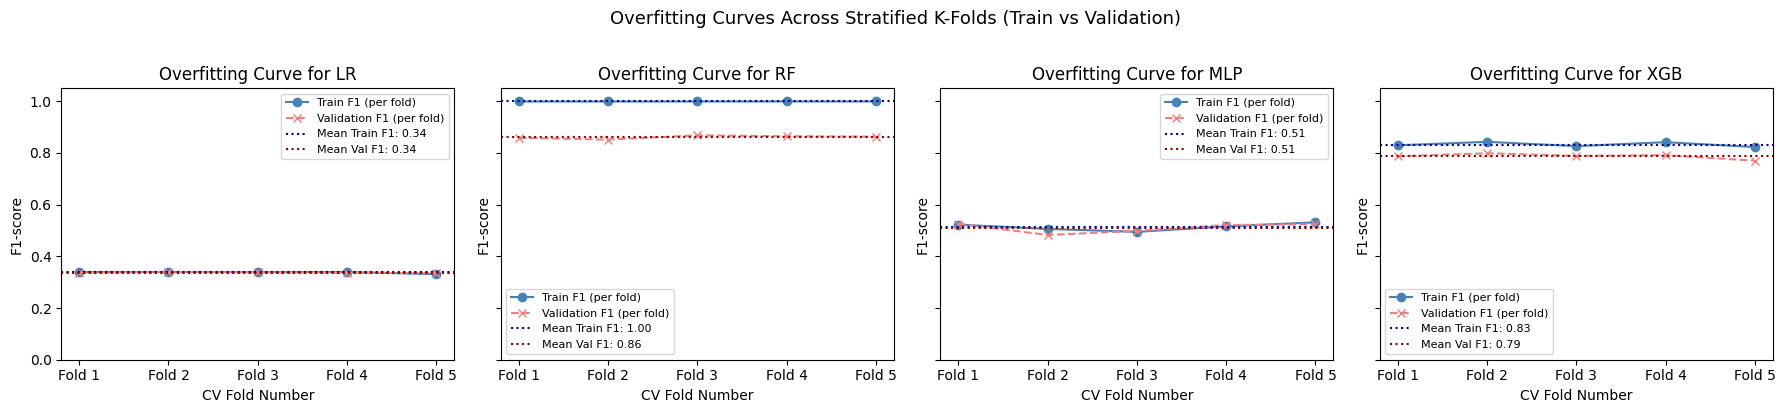

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# Ensure X_cv, y_cv, N_SPLITS, and tscv are defined as in previous cells
# X_cv and y_cv represent the combined original train and validation sets
X_cv = X_temp.values
y_cv = y_temp.values

# N_SPLITS and tscv are defined in cell wThQ1jeupwtA
# For this cell to be runnable independently, we re-define them or ensure they are in scope.
# Re-defining here for clarity, assuming N_SPLITS is 5 and tscv is StratifiedKFold
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight
from tqdm.auto import tqdm

N_SPLITS = 5 # As used in previous CV section
tscv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42) # As used in previous CV section

print("Generating Overfitting Curves (F1-score) using Stratified K-Fold CV...")
print("Each model will be trained and evaluated within each fold.")

cv_overfitting_results = {
    m: {"train_f1": [], "val_f1": []} for m in ["LR", "RF", "MLP", "XGB"]
}

for fold, (train_idx, test_idx) in enumerate(
    tqdm(list(tscv.split(X_cv, y_cv)), desc="CV Folds for Overfitting Curve", unit="fold"), 1
):
    X_f_tr, X_f_te = X_cv[train_idx], X_cv[test_idx]
    y_f_tr, y_f_te = y_cv[train_idx], y_cv[test_idx]

    # Scaling within fold — fit only on fold's train
    sc = MinMaxScaler()
    X_f_tr_scaled = sc.fit_transform(X_f_tr)
    X_f_te_scaled = sc.transform(X_f_te)

    if y_f_te.sum() == 0:
        print(f"  Fold {fold}: skipped (no illicit in test split)")
        continue

    # Class weights for this fold's training data
    # This matches the logic from the CV section (wThQ1jeupwtA)
    sw_f = compute_sample_weight("balanced", y=y_f_tr)
    neg_f = (y_f_tr == 0).sum()
    pos_f = (y_f_tr == 1).sum()
    xgb_scale_pos_f = neg_f / pos_f

    # Initialize new model instances for each fold with appropriate weights
    models_fold = {
        "LR": LogisticRegression(max_iter=1000, class_weight="balanced"),
        "RF": RandomForestClassifier(n_estimators=50, random_state=42, class_weight="balanced"),
        "MLP": MLPClassifier(hidden_layer_sizes=(50,), solver="adam", learning_rate_init=0.001, max_iter=500, random_state=42),
        "XGB": xgb.XGBClassifier(objective="binary:logistic", scale_pos_weight=xgb_scale_pos_f, random_state=42, eval_metric="logloss") # Removed use_label_encoder=False as per notebook's practice
    }

    for mname, model in models_fold.items():
        model.fit(X_f_tr_scaled, y_f_tr)

        # Predict and calculate F1 for training set of this fold
        y_pred_tr = model.predict(X_f_tr_scaled)
        train_f1 = f1_score(y_f_tr, y_pred_tr, average='binary', pos_label=1, zero_division=0)
        cv_overfitting_results[mname]["train_f1"].append(train_f1)

        # Predict and calculate F1 for validation (test) set of this fold
        y_pred_te = model.predict(X_f_te_scaled)
        val_f1 = f1_score(y_f_te, y_pred_te, average='binary', pos_label=1, zero_division=0)
        cv_overfitting_results[mname]["val_f1"].append(val_f1)

# Calculate mean F1 scores across folds
mean_train_f1 = {m: np.mean(res["train_f1"]) for m, res in cv_overfitting_results.items()}
mean_val_f1 = {m: np.mean(res["val_f1"]) for m, res in cv_overfitting_results.items()}

print("\nMean F1-scores across folds:")
for m in mean_train_f1.keys():
    print(f"  {m:<5} - Train F1: {mean_train_f1[m]:.3f}, Val F1: {mean_val_f1[m]:.3f}")

# Plotting separate overfitting curves for each model
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True) # Use shared axes for better comparison
axes = axes.flatten() # Flatten in case of 2D array

for i, mname in enumerate(cv_overfitting_results.keys()):
    ax = axes[i]
    x_data = range(len(cv_overfitting_results[mname]["train_f1"])) # Folds as x-axis

    ax.plot(x_data, cv_overfitting_results[mname]["train_f1"], marker='o', linestyle='-', color='steelblue', label='Train F1 (per fold)')
    ax.plot(x_data, cv_overfitting_results[mname]["val_f1"], marker='x', linestyle='--', color='lightcoral', label='Validation F1 (per fold)')

    ax.axhline(mean_train_f1[mname], color='darkblue', linestyle=':', label=f'Mean Train F1: {mean_train_f1[mname]:.2f}')
    ax.axhline(mean_val_f1[mname], color='darkred', linestyle=':', label=f'Mean Val F1: {mean_val_f1[mname]:.2f}')

    ax.set_ylabel('F1-score')
    ax.set_xlabel('CV Fold Number')
    ax.set_title(f'Overfitting Curve for {mname}') # Title for each subplot
    ax.set_xticks(x_data)
    ax.set_xticklabels([f'Fold {j+1}' for j in x_data])
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.05)

plt.suptitle("Overfitting Curves Across Stratified K-Folds (Train vs Validation)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 10: Feature Importance Analysis (Validation-Set Based)

All three importance methods now use the **validation set** for scoring. This avoids inflating importance for features
the model has simply memorised.


Top 10 features (MDI):


,Feature,MDI_Importance
0,first_sent_block,0.070817
1,transacted_w_address_total,0.046871
2,fees_as_share_max,0.045965
3,fees_min,0.041564
4,btc_sent_max,0.037139
5,fees_max,0.036448
6,fees_mean,0.035679
7,last_block_appeared_in,0.035418
8,fees_as_share_total,0.035135
9,first_block_appeared_in,0.034554


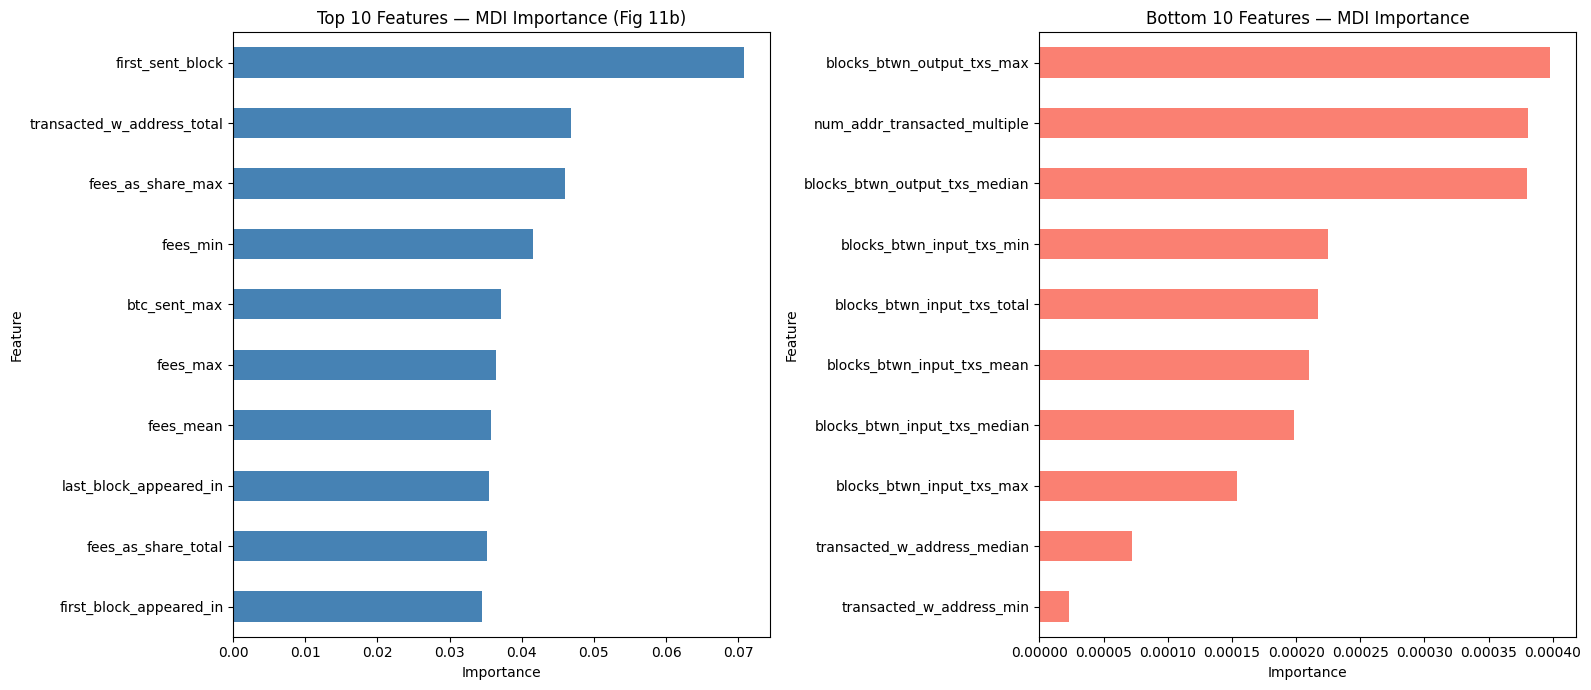

In [ ]:
# ── 10.1 MDI importance (from trained RF) ────────────────────────────────────
imp_df = pd.DataFrame({
    "Feature": feature_names,
    "MDI_Importance": cRF.feature_importances_
}).sort_values("MDI_Importance", ascending=False).reset_index(drop=True)

print("Top 10 features (MDI):")
display(imp_df.head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
imp_df.head(10).iloc[::-1].plot(kind="barh", x="Feature", y="MDI_Importance",
                                 ax=axes[0], color="steelblue", legend=False)
axes[0].set_title("Top 10 Features — MDI Importance (Fig 11b)")
axes[0].set_xlabel("Importance")
imp_df.tail(10).iloc[::-1].plot(kind="barh", x="Feature", y="MDI_Importance",
                                 ax=axes[1], color="salmon", legend=False)
axes[1].set_title("Bottom 10 Features — MDI Importance")
axes[1].set_xlabel("Importance")
plt.tight_layout(); plt.show()


In [ ]:
# ── 10.2 Permutation importance (validation set) ─────────────────────────────
try:
    from eli5.sklearn import PermutationImportance
    # Use X_val (validation set) — NOT training set
    perm = PermutationImportance(cRF, random_state=1).fit(X_val, y_val.values)
    perm_imp_df = pd.DataFrame({
        "Feature": feature_names,
        "Perm_Importance": perm.feature_importances_,
        "Perm_Std":        perm.feature_importances_std_
    }).sort_values("Perm_Importance", ascending=False).reset_index(drop=True)
    print("Top 10 features (Permutation Importance — validation set):")
    display(perm_imp_df.head(10))
except ImportError:
    print("eli5 not found. Run: pip install eli5")
    perm_imp_df = None


Top 10 features (Permutation Importance — validation set):


,Feature,Perm_Importance,Perm_Std
0,first_sent_block,0.014396,0.000177
1,fees_max,0.012406,0.000232
2,transacted_w_address_total,0.012240,0.000313
3,fees_as_share_max,0.011728,0.000288
4,first_received_block,0.010232,0.000223
5,fees_min,0.007842,0.000154
6,fees_as_share_total,0.005641,0.000246
7,fees_as_share_mean,0.005393,0.000260
8,last_block_appeared_in,0.004797,0.000331
9,fees_as_share_median,0.004081,0.000180


In [ ]:
# ── 10.3 Drop-column importance (validation set) ─────────────────────────────
# KEY FIX: score on X_val/y_val (unseen data), not training data
print("Computing drop-column importance using VALIDATION SET...")
print("(This trains 56 RF clones — may take a few minutes)")

# Baseline: score on validation set
model_clone = clone(cRF)
model_clone.fit(X_train, y_train.values)
benchmark_score = model_clone.score(X_val, y_val.values)
print(f"Baseline val accuracy: {benchmark_score:.4f}")

drop_importances = []
X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_val_df   = pd.DataFrame(X_val,   columns=feature_names)

for col in tqdm(feature_names, desc="Drop-column importance", unit="feature"):
    mc = clone(cRF)
    mc.fit(X_train_df.drop(col, axis=1).values, y_train.values)
    # Score on validation set without this column
    drop_score = mc.score(X_val_df.drop(col, axis=1).values, y_val.values)
    drop_importances.append(benchmark_score - drop_score)

drop_imp_df = pd.DataFrame({
    "Feature":        feature_names,
    "Drop_Importance": drop_importances
}).sort_values("Drop_Importance", ascending=False).reset_index(drop=True)

print("\nTop 10 features (Drop-column — validation set):")
display(drop_imp_df.head(10))


Computing drop-column importance using VALIDATION SET...
(This trains 56 RF clones — may take a few minutes)
Baseline val accuracy: 0.9865


Drop-column importance:   0%|          | 0/55 [00:00<?, ?feature/s]


Top 10 features (Drop-column — validation set):


,Feature,Drop_Importance
0,transacted_w_address_total,0.000867
1,first_sent_block,0.000396
2,fees_min,0.000339
3,last_block_appeared_in,0.000207
4,fees_as_share_max,0.000151
5,fees_max,0.000075
6,first_block_appeared_in,0.000075
7,blocks_btwn_output_txs_max,0.000057
8,btc_received_median,0.000019
9,fees_total,-0.000038


In [ ]:
# ── 10.4 Combine all three rankings ──────────────────────────────────────────
combined_imp = imp_df.merge(drop_imp_df, on="Feature")
if perm_imp_df is not None:
    combined_imp = combined_imp.merge(
        perm_imp_df[["Feature","Perm_Importance"]], on="Feature")
    combined_imp["Combined_Rank"] = (
        combined_imp["MDI_Importance"].rank(ascending=False) +
        combined_imp["Drop_Importance"].rank(ascending=False) +
        combined_imp["Perm_Importance"].rank(ascending=False))
else:
    combined_imp["Combined_Rank"] = (
        combined_imp["MDI_Importance"].rank(ascending=False) +
        combined_imp["Drop_Importance"].rank(ascending=False))

combined_imp = combined_imp.sort_values("Combined_Rank").reset_index(drop=True)

# Top 35% of 56 features = 19 features
TOP_N = max(10, int(len(feature_names) * 0.35))
selected_features = combined_imp.head(TOP_N)["Feature"].tolist()
print(f"Selected top {TOP_N} features (out of {len(feature_names)}):")
print(selected_features)


Selected top 19 features (out of 55):
['first_sent_block', 'transacted_w_address_total', 'fees_as_share_max', 'fees_min', 'fees_max', 'last_block_appeared_in', 'first_block_appeared_in', 'fees_as_share_total', 'fees_mean', 'fees_median', 'fees_total', 'first_received_block', 'fees_as_share_median', 'btc_received_median', 'fees_as_share_min', 'btc_sent_max', 'btc_sent_total', 'total_txs', 'btc_transacted_max']


Computing SHAP values for RF on validation set (sampled)...


SHAP TreeExplainer:   0%|          | 0/1 [00:00<?, ?batch/s]

shap_illicit shape: (2000, 55)  (expected: 2000 x 55)


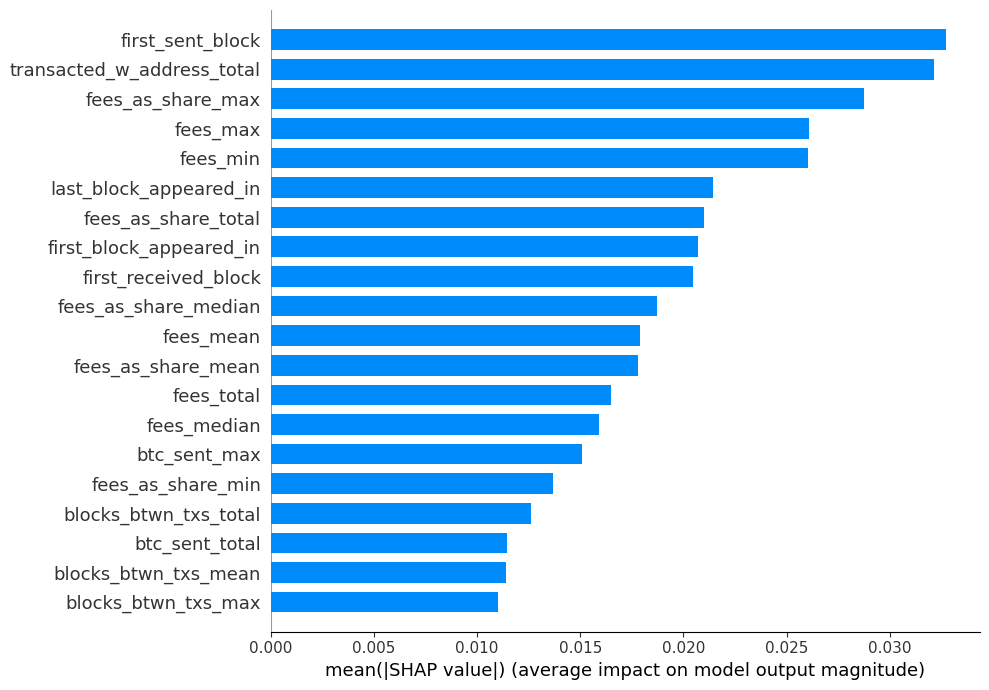

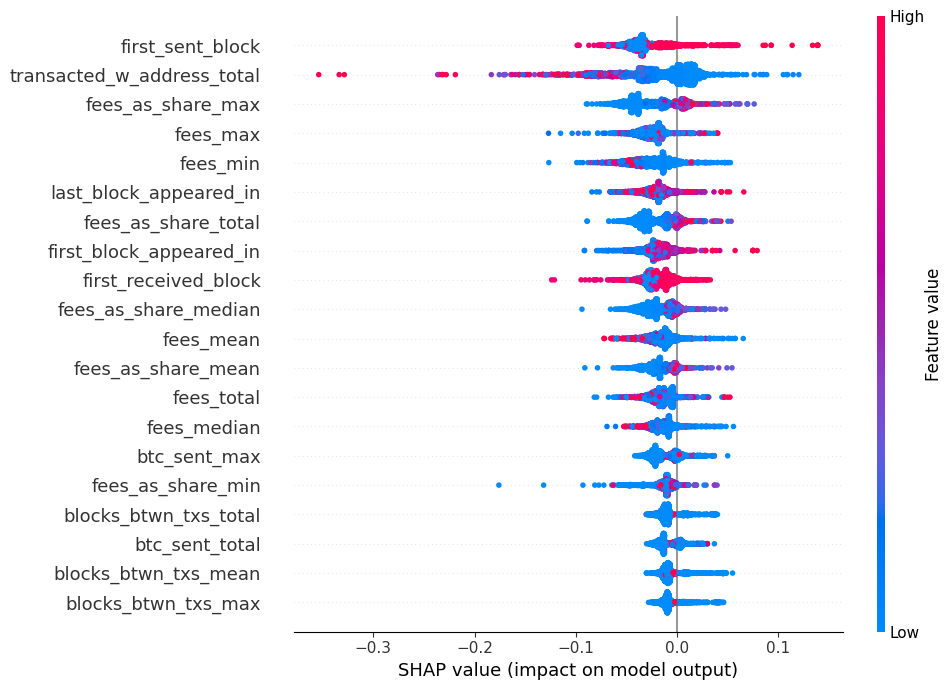

In [ ]:
# ── 10.5 SHAP analysis on RF (validation set) ────────────────────────────────
# SHAP logic:
#   - TreeExplainer is the correct explainer for tree-based models (RF, XGB).
#   - shap_values() returns a list [class_0_vals, class_1_vals] for binary
#     classification in older SHAP, or a single 3-D array in newer SHAP.
#   - We always extract the illicit (positive) class slice.
#   - We sample 2,000 rows from X_val to keep computation fast; SHAP values
#     on a sample are statistically representative for summary plots.

print("Computing SHAP values for RF on validation set (sampled)...")

# Sample for speed — 2,000 rows is sufficient for summary plots
rng = np.random.default_rng(42)
shap_sample_idx = rng.choice(len(X_val), size=min(2000, len(X_val)), replace=False)
X_val_shap = X_val[shap_sample_idx]

explainer_rf = shap.TreeExplainer(cRF)

# Compute with progress indication via tqdm wrapping the row batches
# (TreeExplainer processes all rows in one call internally; we wrap the
#  single call in a tqdm context just to show a spinner while it runs)
with tqdm(total=1, desc="SHAP TreeExplainer", unit="batch") as pbar:
    shap_vals_rf = explainer_rf.shap_values(X_val_shap)
    pbar.update(1)

# Handle both old (list per class) and new (single 3-D array) SHAP formats
# Old SHAP (< 0.40): shap_values returns [shap_class0, shap_class1]
# New SHAP (>= 0.40): returns a single array of shape (n_samples, n_features, n_classes)
if isinstance(shap_vals_rf, list):
    # Binary classification: index 1 = illicit class
    shap_illicit = shap_vals_rf[1]
elif shap_vals_rf.ndim == 3:
    # New format: last axis is the class axis
    shap_illicit = shap_vals_rf[:, :, 1]
else:
    # Single-output or already 2-D (some XGB paths)
    shap_illicit = shap_vals_rf

print(f"shap_illicit shape: {shap_illicit.shape}  "
      f"(expected: {X_val_shap.shape[0]} x {X_val_shap.shape[1]})")

X_val_shap_df = pd.DataFrame(X_val_shap, columns=feature_names)

# Bar summary — mean |SHAP| per feature
shap.summary_plot(shap_illicit, X_val_shap_df,
                  plot_type="bar", max_display=20, plot_size=(10,7), show=True)

# Beeswarm — direction + magnitude
shap.summary_plot(shap_illicit, X_val_shap_df,
                  max_display=20, plot_size=(10,7))


Dependence plot for top feature: first_sent_block


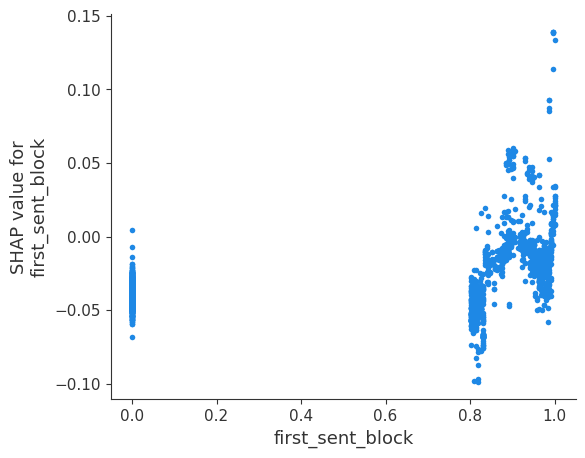

In [ ]:
# ── 10.6 SHAP dependence plot — top feature ──────────────────────────────────
top_feature = imp_df["Feature"].iloc[0]
print(f"Dependence plot for top feature: {top_feature}")
shap.dependence_plot(
    top_feature, shap_illicit,
    X_val_shap_df,          # use the same sampled DataFrame used for SHAP
    interaction_index=None)


Computing SHAP values for feature-refined XGBoost on validation set (sampled)...


SHAP TreeExplainer (XGBoost):   0%|          | 0/1 [00:00<?, ?batch/s]

shap_illicit_xgb shape: (2000, 19)  (expected: 2000 x 19)者に)

SHAP Summary Plot (Bar) for XGBoost:


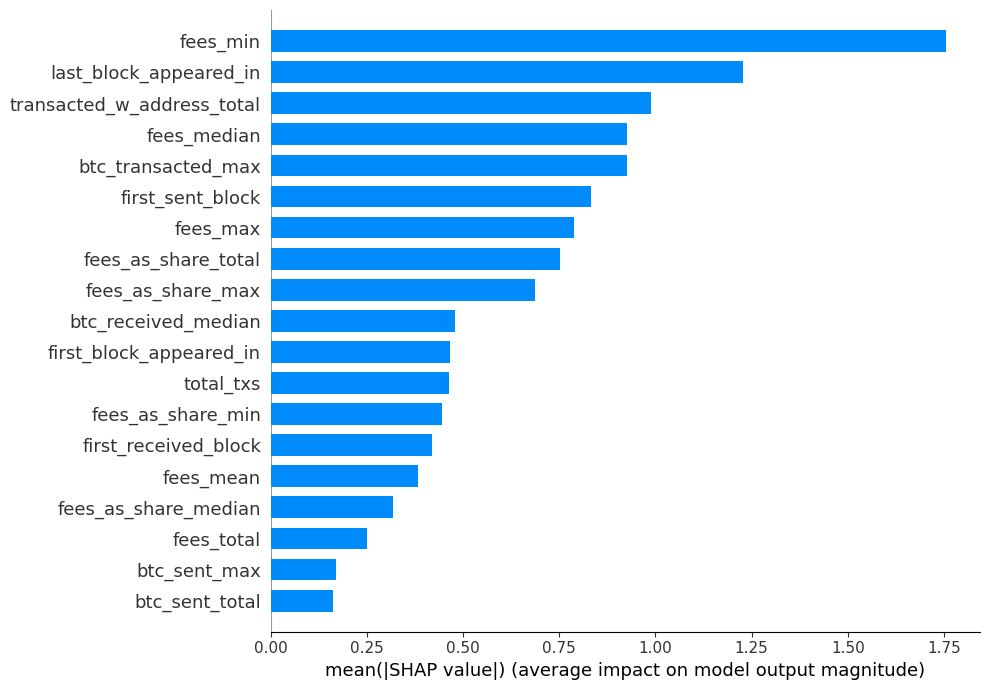


SHAP Beeswarm Plot for XGBoost:


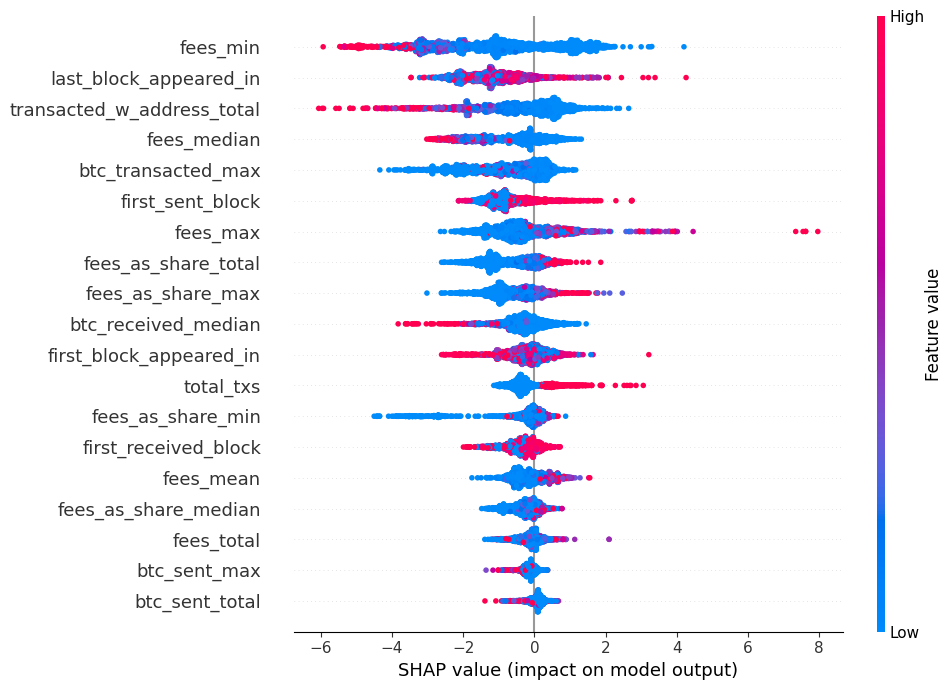


SHAP Dependence plot for top feature: first_sent_block (XGBoost)


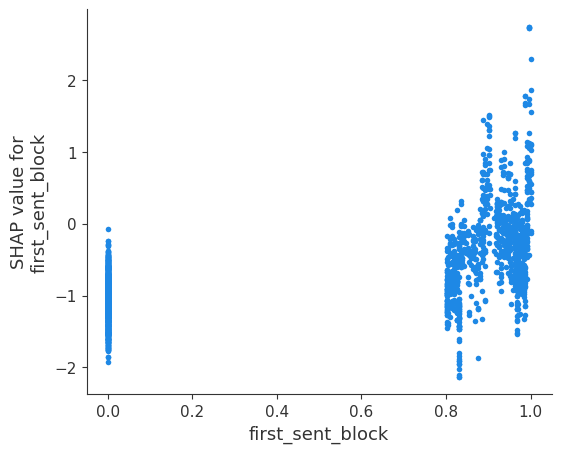

In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming cXGB_sel, X_val_sel, y_val, and selected_features are available from previous cells

print("Computing SHAP values for feature-refined XGBoost on validation set (sampled)...")

# Sample for speed — 2,000 rows is sufficient for summary plots
rng = np.random.default_rng(42)
shap_sample_size = min(2000, len(X_val_sel))
shap_sample_idx = rng.choice(len(X_val_sel), size=shap_sample_size, replace=False)
X_val_sel_shap = X_val_sel[shap_sample_idx]

# Ensure feature names are aligned with the selected features for SHAP plots
feature_names_sel = selected_features
X_val_sel_shap_df = pd.DataFrame(X_val_sel_shap, columns=feature_names_sel)

explainer_xgb = shap.TreeExplainer(cXGB_sel)

# Compute with progress indication via tqdm
from tqdm.auto import tqdm
with tqdm(total=1, desc="SHAP TreeExplainer (XGBoost)", unit="batch") as pbar:
    shap_vals_xgb = explainer_xgb.shap_values(X_val_sel_shap)
    pbar.update(1)

# Handle both old (list per class) and new (single 3-D array) SHAP formats
# This logic ensures we get a (n_samples, n_features) array for the illicit class
if isinstance(shap_vals_xgb, list):
    # Binary classification: index 1 = illicit class
    shap_illicit_xgb = shap_vals_xgb[1]
elif shap_vals_xgb.ndim == 3:
    # New format: last axis is the class axis
    shap_illicit_xgb = shap_vals_xgb[:, :, 1]
else:
    # If it's already a 2D array (n_samples, n_features), assume it's for the positive class
    shap_illicit_xgb = shap_vals_xgb


print(f"shap_illicit_xgb shape: {shap_illicit_xgb.shape}  " \
      f"(expected: {X_val_sel_shap.shape[0]} x {X_val_sel_shap.shape[1]})者に)")

# Bar summary — mean |SHAP| per feature
print("\nSHAP Summary Plot (Bar) for XGBoost:")
shap.summary_plot(shap_illicit_xgb, X_val_sel_shap_df,
                  plot_type="bar", max_display=len(feature_names_sel), plot_size=(10,7), show=True)

# Beeswarm — direction + magnitude
print("\nSHAP Beeswarm Plot for XGBoost:")
shap.summary_plot(shap_illicit_xgb, X_val_sel_shap_df,
                  max_display=len(feature_names_sel), plot_size=(10,7))

# SHAP dependence plot — for the top feature
# Re-using the top feature from the combined importance analysis
# Assuming 'first_sent_block' is still relevant and present in selected_features
if selected_features and 'first_sent_block' in selected_features:
    top_feature_for_shap = 'first_sent_block'
elif selected_features:
    # Fallback to the highest MDI importance feature if 'first_sent_block' is not in selected_features
    top_feature_for_shap = imp_df[imp_df['Feature'].isin(selected_features)].iloc[0]['Feature']
else:
    top_feature_for_shap = None

if top_feature_for_shap:
    print(f"\nSHAP Dependence plot for top feature: {top_feature_for_shap} (XGBoost)")
    shap.dependence_plot(
        top_feature_for_shap, shap_illicit_xgb,
        X_val_sel_shap_df,
        interaction_index=None
    )
else:
    print("Could not determine a top feature for dependence plot as selected_features is empty.")

plt.show()

---
## Section 11: Feature-Refined Models

Re-train all models on the top 19 selected features.
Evaluate on validation set. Final test-set metrics at the end.


In [ ]:
# Slice to selected features
X_train_sel = pd.DataFrame(X_train, columns=feature_names)[selected_features].values
X_val_sel   = pd.DataFrame(X_val,   columns=feature_names)[selected_features].values
X_test_sel  = pd.DataFrame(X_test,  columns=feature_names)[selected_features].values

print(f"Refined feature shape — train: {X_train_sel.shape}  "
      f"val: {X_val_sel.shape}  test: {X_test_sel.shape}")


Refined feature shape — train: (159212, 19)  val: (53071, 19)  test: (53071, 19)


In [ ]:
results_refined = []
print("FEATURE-REFINED MODELS — evaluated on VALIDATION SET")
print("=" * 105)

# LR — selected features
cLR_sel = LogisticRegression(max_iter=1000, class_weight="balanced")
cLR_sel.fit(X_train_sel, y_train.values)
evaluate("LR (Selected)", y_val.values, cLR_sel.predict(X_val_sel), results_refined)

# RF — selected features
cRF_sel = RandomForestClassifier(n_estimators=best_n, random_state=42,
                                  class_weight="balanced")
cRF_sel.fit(X_train_sel, y_train.values)
evaluate("RF (Selected)", y_val.values, cRF_sel.predict(X_val_sel), results_refined)

# MLP — selected features
cMLP_sel = MLPClassifier(hidden_layer_sizes=(50,), solver="adam",
                          learning_rate_init=0.001, max_iter=500, random_state=42)
cMLP_sel.fit(X_train_sel, y_train.values)
evaluate("MLP (Selected)", y_val.values, cMLP_sel.predict(X_val_sel), results_refined)

# XGB — selected features
cXGB_sel = xgb.XGBClassifier(objective="binary:logistic",
                               n_estimators=best_n_xgb,
                               max_depth=best_max_depth_xgb,
                               scale_pos_weight=xgb_scale_pos,
                               random_state=42, eval_metric="logloss")
cXGB_sel.fit(X_train_sel, y_train.values)
evaluate("XGB (Selected)", y_val.values, cXGB_sel.predict(X_val_sel), results_refined)

FEATURE-REFINED MODELS — evaluated on VALIDATION SET
  LR (Selected)                                 Prec=0.213  Rec=0.688  F1=0.326  MCC=0.326  Acc=0.851  [val]
  RF (Selected)                                 Prec=0.961  Rec=0.799  F1=0.872  MCC=0.870  Acc=0.988  [val]
  MLP (Selected)                                Prec=0.848  Rec=0.327  F1=0.472  MCC=0.513  Acc=0.962  [val]
  XGB (Selected)                                Prec=0.800  Rec=0.930  F1=0.860  MCC=0.854  Acc=0.984  [val]


{'Model': 'XGB (Selected)',
 'Split': 'val',
 'Precision': np.float64(0.8),
 'Recall': np.float64(0.93),
 'F1': np.float64(0.86),
 'Micro-F1': 0.984,
 'MCC': np.float64(0.854),
 'Accuracy': np.float64(0.984)}

In [ ]:
# ── Before vs After comparison table ─────────────────────────────────────────
df_before = pd.DataFrame(results)
df_after  = pd.DataFrame(results_refined)

def clean_name(name):
    n = str(name).lower()
    if "logistic" in n or (n.startswith("lr") and "ensemble" not in n): return "LR"
    elif ("random" in n or n.startswith("rf")) and "ensemble" not in n: return "RF"
    elif "mlp" in n and "ensemble" not in n:  return "MLP"
    elif "xgb" in n and "ensemble" not in n:  return "XGB"
    else: return name

df_before["Model"] = df_before["Model"].apply(clean_name)
df_after["Model"]  = df_after["Model"].apply(clean_name)
valid = ["LR","RF","MLP","XGB"]
df_b = df_before[df_before["Model"].isin(valid)].drop_duplicates(subset="Model", keep="first")
df_a = df_after[df_after["Model"].isin(valid)].drop_duplicates(subset="Model", keep="first")

comp = df_b.merge(df_a, on="Model", suffixes=("_Before","_After"))
comp = comp[["Model","Precision_Before","Precision_After",
             "Recall_Before","Recall_After","F1_Before","F1_After",
             "MCC_Before","MCC_After"]]
comp["F1_Δ"]     = (comp["F1_After"]     - comp["F1_Before"]).round(3)
comp["Recall_Δ"] = (comp["Recall_After"] - comp["Recall_Before"]).round(3)
print("\nBefore vs After Feature Selection (Validation Set):")
display(comp)



Before vs After Feature Selection (Validation Set):


,Model,Precision_Before,Precision_After,Recall_Before,Recall_After,F1_Before,F1_After,MCC_Before,MCC_After,F1_Δ,Recall_Δ
0,LR,0.211,0.213,0.687,0.688,0.323,0.326,0.323,0.326,0.003,0.001
1,RF,0.958,0.961,0.776,0.799,0.857,0.872,0.856,0.870,0.015,0.023
2,MLP,0.777,0.848,0.391,0.327,0.520,0.472,0.535,0.513,-0.048,-0.064
3,XGB,0.660,0.650,0.946,0.944,0.777,0.770,0.777,0.770,-0.007,-0.002


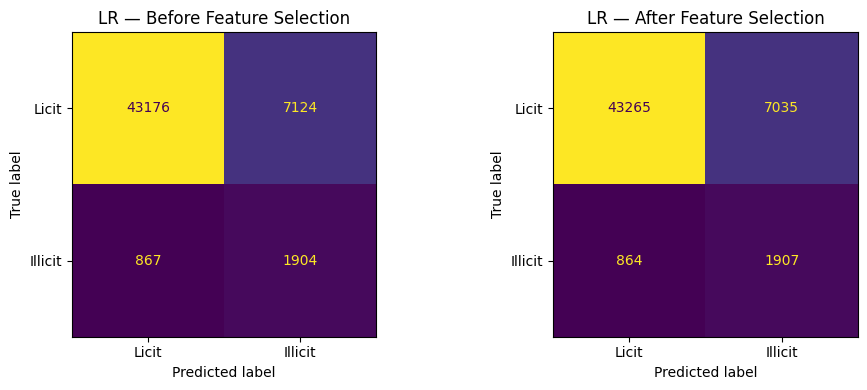

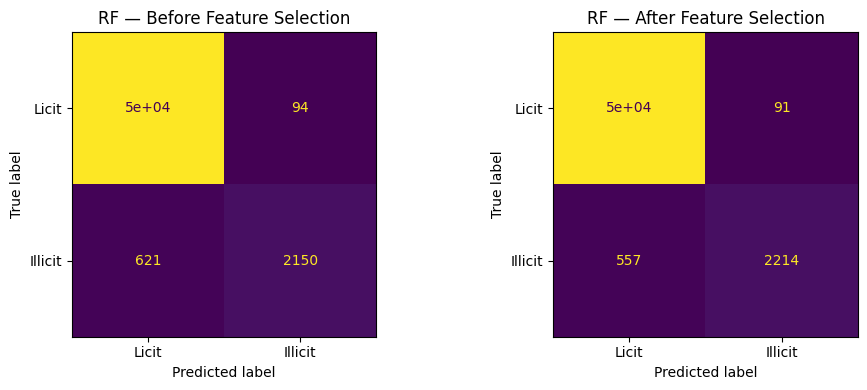

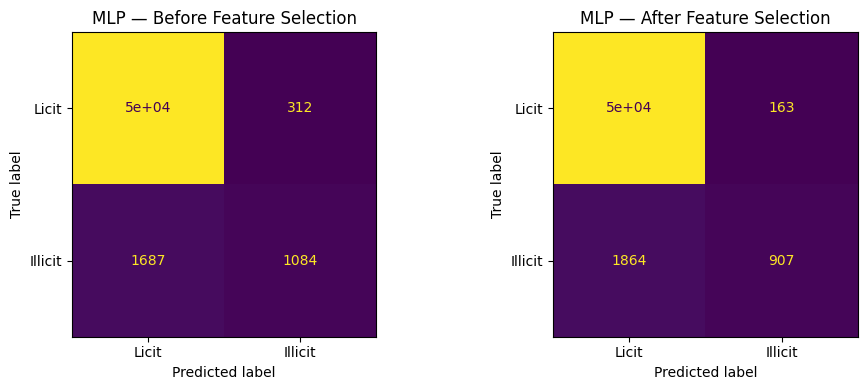

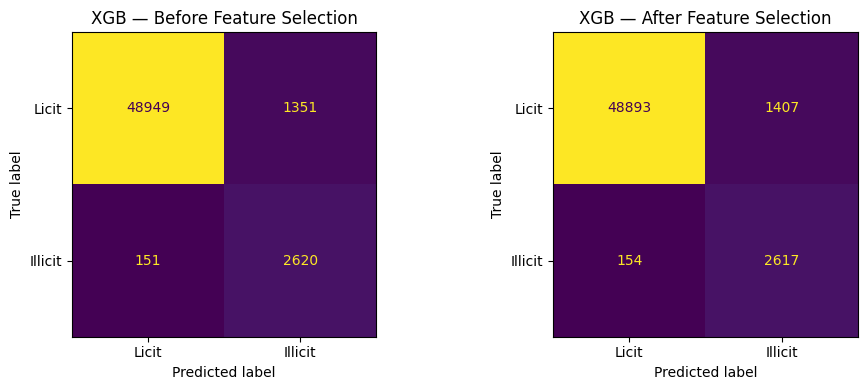

In [ ]:
# ── Confusion matrices — before vs after feature selection ────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_before_after_cm(y_true, y_before, y_after, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_before),
                           display_labels=["Licit","Illicit"]).plot(
        ax=axes[0], colorbar=False)
    axes[0].set_title(f"{model_name} — Before Feature Selection")
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_after),
                           display_labels=["Licit","Illicit"]).plot(
        ax=axes[1], colorbar=False)
    axes[1].set_title(f"{model_name} — After Feature Selection")
    plt.tight_layout(); plt.show()

plot_before_after_cm(y_val.values, cLR.predict(X_val),   cLR_sel.predict(X_val_sel),  "LR")
plot_before_after_cm(y_val.values, cRF.predict(X_val),   cRF_sel.predict(X_val_sel),  "RF")
plot_before_after_cm(y_val.values, cMLP.predict(X_val),  cMLP_sel.predict(X_val_sel), "MLP")
plot_before_after_cm(y_val.values, cXGB.predict(X_val),  cXGB_sel.predict(X_val_sel), "XGB")


Generating Overfitting Curves (F1-score) on Train vs Val (After Feature Selection)...

  LR (Selected)   - Train F1: 0.337, Val F1: 0.326
  RF (Selected)   - Train F1: 1.000, Val F1: 0.872
  MLP (Selected)  - Train F1: 0.494, Val F1: 0.472
  XGB (Selected)  - Train F1: 0.831, Val F1: 0.770


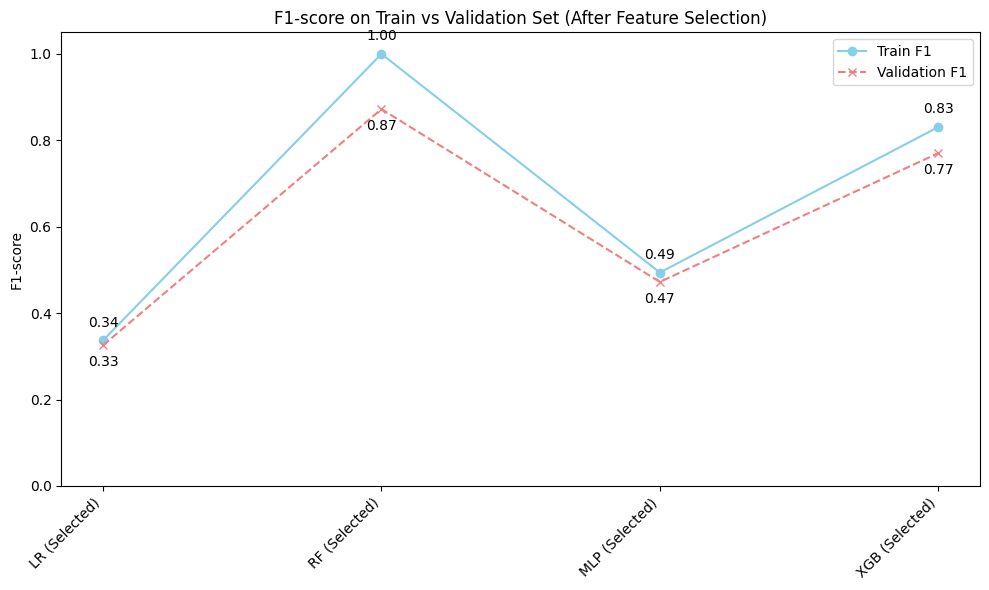

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

print("Generating Overfitting Curves (F1-score) on Train vs Val (After Feature Selection)...\n")

models_refined = {
    "LR (Selected)": cLR_sel,
    "RF (Selected)": cRF_sel,
    "MLP (Selected)": cMLP_sel,
    "XGB (Selected)": cXGB_sel
}

model_names_refined = list(models_refined.keys())
train_f1_scores_refined = []
val_f1_scores_refined = []

for name, model in models_refined.items():
    # Predict on training set with selected features
    y_pred_train_sel = model.predict(X_train_sel)
    f1_train_sel = f1_score(y_train, y_pred_train_sel, average='binary', pos_label=1, zero_division=0)
    train_f1_scores_refined.append(f1_train_sel)

    # Predict on validation set with selected features
    y_pred_val_sel = model.predict(X_val_sel)
    f1_val_sel = f1_score(y_val, y_pred_val_sel, average='binary', pos_label=1, zero_division=0)
    val_f1_scores_refined.append(f1_val_sel)

    print(f"  {name:<15} - Train F1: {f1_train_sel:.3f}, Val F1: {f1_val_sel:.3f}")

x_refined = range(len(model_names_refined))

fig_refined, ax_refined = plt.subplots(figsize=(10, 6))
ax_refined.plot(x_refined, train_f1_scores_refined, marker='o', linestyle='-', color='skyblue', label='Train F1')
ax_refined.plot(x_refined, val_f1_scores_refined, marker='x', linestyle='--', color='lightcoral', label='Validation F1')

ax_refined.set_ylabel('F1-score')
ax_refined.set_title('F1-score on Train vs Validation Set (After Feature Selection)')
ax_refined.set_xticks(x_refined)
ax_refined.set_xticklabels(model_names_refined, rotation=45, ha='right')
ax_refined.legend()
ax_refined.set_ylim(0, 1.05)

# Adding text labels for the F1 scores at each point
for i, txt in enumerate(train_f1_scores_refined):
    ax_refined.annotate(f'{txt:.2f}', (x_refined[i], train_f1_scores_refined[i]), textcoords="offset points", xytext=(0,10), ha='center')
for i, txt in enumerate(val_f1_scores_refined):
    ax_refined.annotate(f'{txt:.2f}', (x_refined[i], val_f1_scores_refined[i]), textcoords="offset points", xytext=(0,-15), ha='center')

plt.tight_layout()
plt.show()

Running Stratified K-Fold CV with 5 folds for REFINED models...


CV Folds (Refined):   0%|          | 0/5 [00:00<?, ?fold/s]


Fold 1  train=169,826  test=42,457  illicit_test=2290
  LR (Selected)    Prec=0.218  Rec=0.709  F1=0.333  MCC=0.335  Acc=0.847  Train_F1=0.337
  RF (Selected)    Prec=0.963  Rec=0.800  F1=0.874  MCC=0.871  Acc=0.988  Train_F1=1.000
  MLP (Selected)   Prec=0.851  Rec=0.360  F1=0.506  MCC=0.539  Acc=0.962  Train_F1=0.500
  XGB (Selected)   Prec=0.812  Rec=0.918  F1=0.862  MCC=0.855  Acc=0.984  Train_F1=0.937

Fold 2  train=169,826  test=42,457  illicit_test=2290
  LR (Selected)    Prec=0.224  Rec=0.696  F1=0.339  MCC=0.338  Acc=0.854  Train_F1=0.337
  RF (Selected)    Prec=0.959  Rec=0.794  F1=0.869  MCC=0.867  Acc=0.987  Train_F1=1.000
  MLP (Selected)   Prec=0.799  Rec=0.358  F1=0.494  MCC=0.519  Acc=0.961  Train_F1=0.513
  XGB (Selected)   Prec=0.808  Rec=0.924  F1=0.862  MCC=0.856  Acc=0.984  Train_F1=0.935

Fold 3  train=169,826  test=42,457  illicit_test=2291
  LR (Selected)    Prec=0.220  Rec=0.664  F1=0.330  MCC=0.324  Acc=0.855  Train_F1=0.333
  RF (Selected)    Prec=0.963  Rec

,Precision (μ±σ),Recall (μ±σ),F1 (μ±σ),MCC (μ±σ),Accuracy (μ±σ)
Model,,,,,
LR (Selected),0.220 ± 0.002,0.702 ± 0.022,0.334 ± 0.003,0.334 ± 0.006,0.849 ± 0.004
RF (Selected),0.960 ± 0.003,0.808 ± 0.012,0.878 ± 0.008,0.875 ± 0.007,0.988 ± 0.001
MLP (Selected),0.823 ± 0.041,0.360 ± 0.023,0.499 ± 0.016,0.528 ± 0.008,0.961 ± 0.001
XGB (Selected),0.805 ± 0.008,0.928 ± 0.008,0.862 ± 0.005,0.856 ± 0.005,0.984 ± 0.001


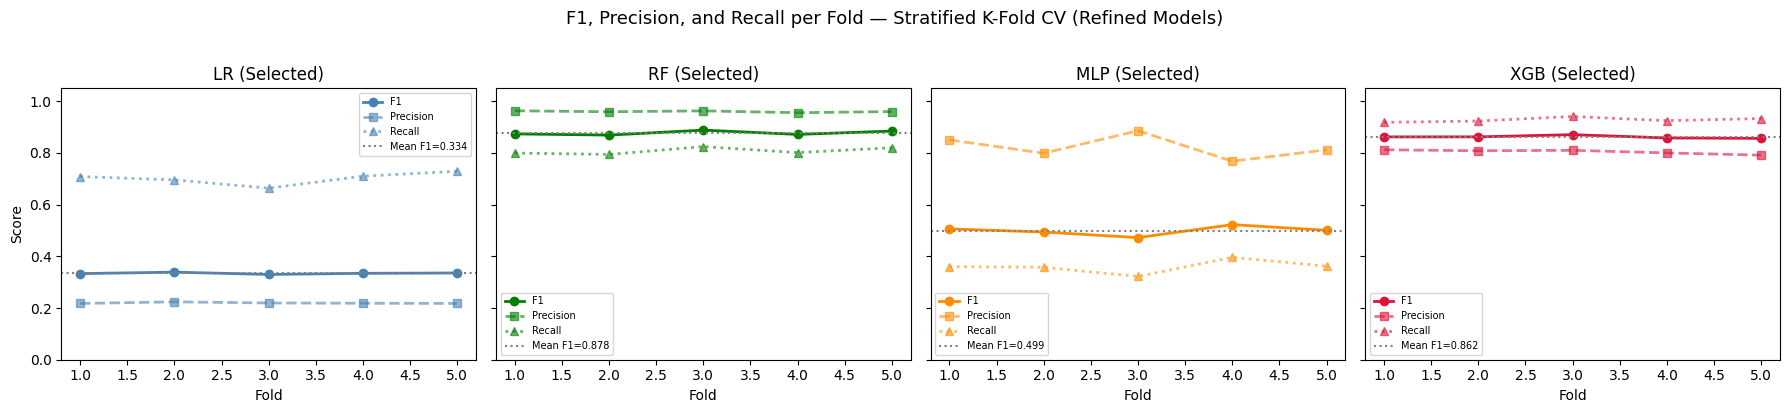

In [ ]:
from sklearn.model_selection import StratifiedKFold

print(f"Running Stratified K-Fold CV with {N_SPLITS} folds for REFINED models...")
print("=" * 80)

cv_results_refined = {m: {"precision":[],"recall":[],"f1":[],"mcc":[],"accuracy":[], "train_f1":[]} # Added train_f1
                      for m in ["LR (Selected)","RF (Selected)","MLP (Selected)","XGB (Selected)"]}

# Ensure X_temp and y_temp are used, as these are the combined train and val sets before final split
X_cv_temp_df = pd.DataFrame(X_temp, columns=feature_names)
y_cv_temp = y_temp.values

for fold, (train_idx, test_idx) in enumerate(
        tqdm(list(tscv.split(X_cv_temp_df, y_cv_temp)), desc="CV Folds (Refined)", unit="fold"), 1):

    X_f_tr_raw, X_f_te_raw = X_cv_temp_df.iloc[train_idx], X_cv_temp_df.iloc[test_idx]
    y_f_tr, y_f_te = y_cv_temp[train_idx], y_cv_temp[test_idx]

    # Apply feature selection for this fold
    X_f_tr_sel = X_f_tr_raw[selected_features]
    X_f_te_sel = X_f_te_raw[selected_features]

    # Scale within fold — fit only on fold's train data with selected features
    sc_refined = MinMaxScaler()
    X_f_tr_scaled_sel = sc_refined.fit_transform(X_f_tr_sel)
    X_f_te_scaled_sel = sc_refined.transform(X_f_te_sel)

    # Skip folds with no illicit in test (should be less likely with StratifiedKFold)
    if y_f_te.sum() == 0:
        print(f"  Fold {fold}: skipped (no illicit in test split)")
        continue

    # Class weights for this fold
    neg_f = (y_f_tr==0).sum(); pos_f = (y_f_tr==1).sum()
    spos_f = neg_f / pos_f

    print(f"\nFold {fold}  train={len(y_f_tr):,}  test={len(y_f_te):,}  " \
          f"illicit_test={y_f_te.sum()}")

    # ── Models (Refined) ────────────────────────────────────────────────────────
    preds_refined = {}
    preds_refined_train = {}

    lr_f_sel = LogisticRegression(max_iter=1000, class_weight="balanced")
    lr_f_sel.fit(X_f_tr_scaled_sel, y_f_tr)
    preds_refined["LR (Selected)"] = lr_f_sel.predict(X_f_te_scaled_sel)
    preds_refined_train["LR (Selected)"] = lr_f_sel.predict(X_f_tr_scaled_sel)

    rf_f_sel = RandomForestClassifier(n_estimators=best_n, random_state=42,
                                      class_weight="balanced")
    rf_f_sel.fit(X_f_tr_scaled_sel, y_f_tr)
    preds_refined["RF (Selected)"] = rf_f_sel.predict(X_f_te_scaled_sel)
    preds_refined_train["RF (Selected)"] = rf_f_sel.predict(X_f_tr_scaled_sel)

    mlp_f_sel = MLPClassifier(hidden_layer_sizes=(50,), solver="adam",
                              learning_rate_init=0.001, max_iter=500, random_state=42)
    mlp_f_sel.fit(X_f_tr_scaled_sel, y_f_tr)
    preds_refined["MLP (Selected)"] = mlp_f_sel.predict(X_f_te_scaled_sel)
    preds_refined_train["MLP (Selected)"] = mlp_f_sel.predict(X_f_tr_scaled_sel)

    xgb_f_sel = xgb.XGBClassifier(objective="binary:logistic",
                                  n_estimators=best_n_xgb,
                                  max_depth=best_max_depth_xgb,
                                  scale_pos_weight=spos_f,
                                  random_state=42, eval_metric="logloss")
    xgb_f_sel.fit(X_f_tr_scaled_sel, y_f_tr)
    preds_refined["XGB (Selected)"] = xgb_f_sel.predict(X_f_te_scaled_sel)
    preds_refined_train["XGB (Selected)"] = xgb_f_sel.predict(X_f_tr_scaled_sel)

    for mname, ypred in preds_refined.items():
        # Validation/Test F1
        pr, rec, f1_, _ = precision_recall_fscore_support(
            y_f_te, ypred, zero_division=0)
        mcc_ = matthews_corrcoef(y_f_te, ypred)
        accuracy_ = (y_f_te == ypred).mean()
        cv_results_refined[mname]["precision"].append(pr[1])
        cv_results_refined[mname]["recall"].append(rec[1])
        cv_results_refined[mname]["f1"].append(f1_[1])
        cv_results_refined[mname]["mcc"].append(mcc_)
        cv_results_refined[mname]["accuracy"].append(accuracy_)

        # Train F1 for overfitting curve
        train_f1_ = f1_score(y_f_tr, preds_refined_train[mname], average='binary', pos_label=1, zero_division=0)
        cv_results_refined[mname]["train_f1"].append(train_f1_)

        print(f"  {mname:<15}  Prec={pr[1]:.3f}  Rec={rec[1]:.3f}  " \
              f"F1={f1_[1]:.3f}  MCC={mcc_:.3f}  Acc={accuracy_:.3f}  Train_F1={train_f1_:.3f}") # Updated print

# ── CV Summary table — mean ± std for refined models──────────────────────────
print("\n" + "=" * 80)
print("CV Summary (mean \u00b1 std across folds) for Refined Models")
print("=" * 80)

cv_summary_refined = []
for mname, metrics in cv_results_refined.items():
    row = {"Model": mname}
    for metric, vals in metrics.items():
        if vals and metric != 'train_f1': # Exclude train_f1 from summary table for brevity
            row[metric] = f"{np.mean(vals):.3f} \u00b1 {np.std(vals):.3f}"
    cv_summary_refined.append(row)

df_cv_refined = pd.DataFrame(cv_summary_refined).set_index("Model")
df_cv_refined.columns = ["Precision (\u03bc\u00b1\u03c3)","Recall (\u03bc\u00b1\u03c3)","F1 (\u03bc\u00b1\u03c3)","MCC (\u03bc\u00b1\u03c3)","Accuracy (\u03bc\u00b1\u03c3)"]
display(df_cv_refined)

# ── Fold-by-fold F1, Precision, and Recall visualisation for refined models ──
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
colors = {"LR (Selected)":"steelblue","RF (Selected)":"green","MLP (Selected)":"darkorange","XGB (Selected)":"crimson"}

for ax, (mname, metrics) in zip(axes, cv_results_refined.items()):
    folds = range(1, len(metrics["f1"])+1)
    ax.plot(folds, metrics["f1"],    marker="o", color=colors[mname],
            linewidth=2, label="F1")
    ax.plot(folds, metrics["precision"],marker="s", color=colors[mname],
            linewidth=2, linestyle="--", alpha=0.6, label="Precision")
    ax.plot(folds, metrics["recall"],marker="^", color=colors[mname],
            linewidth=2, linestyle=":", alpha=0.6, label="Recall")
    ax.axhline(np.mean(metrics["f1"]), color="gray", linestyle=":",
               label=f"Mean F1={np.mean(metrics['f1']):.3f}")
    ax.set_title(mname, fontsize=12)
    ax.set_xlabel("Fold"); ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7)
axes[0].set_ylabel("Score")
plt.suptitle("F1, Precision, and Recall per Fold — Stratified K-Fold CV (Refined Models)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


Generating Overfitting Curves Across Stratified K-Folds for REFINED Models (Train vs. Validation)...


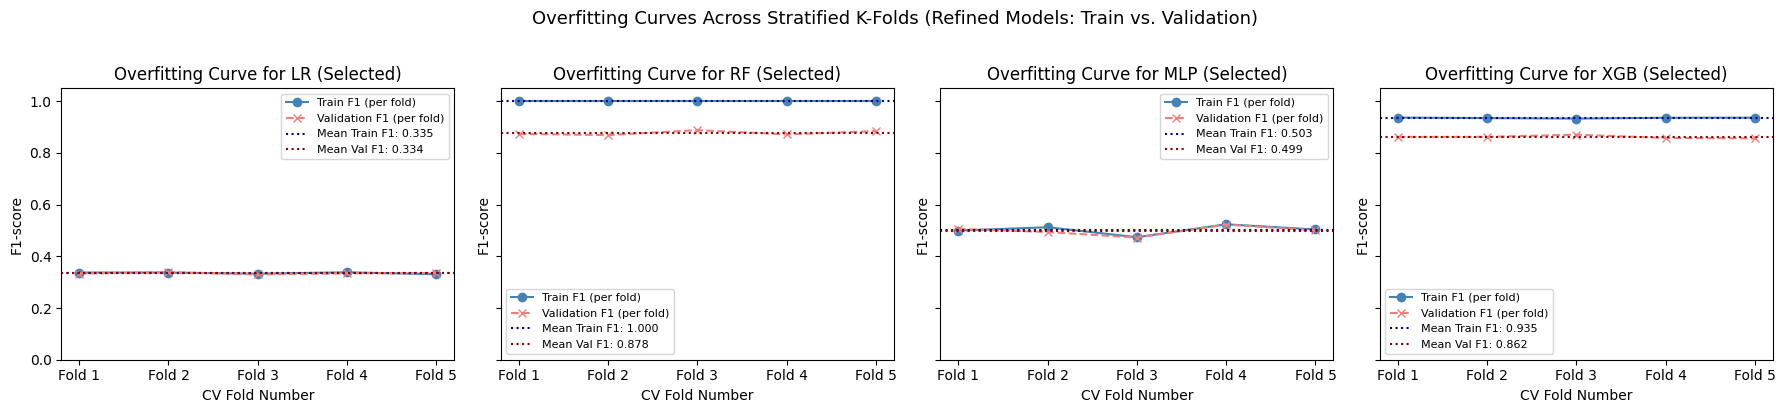

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("Generating Overfitting Curves Across Stratified K-Folds for REFINED Models (Train vs. Validation)...")

# Ensure cv_results_refined is available and now contains 'train_f1' for each fold

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True) # Use shared axes for better comparison
axes = axes.flatten() # Flatten in case of 2D array

colors = {"LR (Selected)":"steelblue","RF (Selected)":"green","MLP (Selected)":"darkorange","XGB (Selected)":"crimson"}

for i, mname in enumerate(cv_results_refined.keys()):
    ax = axes[i]

    folds = range(1, len(cv_results_refined[mname]["f1"]) + 1) # Folds as x-axis

    # Use the 'train_f1' and 'f1' (validation f1) from cv_results_refined
    train_f1_per_fold = cv_results_refined[mname]["train_f1"]
    val_f1_per_fold = cv_results_refined[mname]["f1"]

    ax.plot(folds, train_f1_per_fold, marker='o', linestyle='-', color='steelblue', label='Train F1 (per fold)')
    ax.plot(folds, val_f1_per_fold, marker='x', linestyle='--', color='lightcoral', label='Validation F1 (per fold)')

    # Extract mean F1 from the summary table to use for horizontal lines
    # Assuming the structure of df_cv_refined is 'F1 (μ±σ)' column
    f1_summary_str_val = df_cv_refined.loc[mname, 'F1 (μ±σ)']
    mean_val_f1_from_summary = float(f1_summary_str_val.split(' ')[0])

    # We also need the mean train F1. We can calculate this from the stored per-fold train_f1.
    mean_train_f1_from_stored = np.mean(train_f1_per_fold)

    ax.axhline(mean_train_f1_from_stored, color='darkblue', linestyle=':', label=f'Mean Train F1: {mean_train_f1_from_stored:.3f}')
    ax.axhline(mean_val_f1_from_summary, color='darkred', linestyle=':', label=f'Mean Val F1: {mean_val_f1_from_summary:.3f}')

    ax.set_ylabel('F1-score')
    ax.set_xlabel('CV Fold Number')
    ax.set_title(f'Overfitting Curve for {mname}') # Title for each subplot
    ax.set_xticks(folds)
    ax.set_xticklabels([f'Fold {j}' for j in folds])
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.05)

plt.suptitle("Overfitting Curves Across Stratified K-Folds (Refined Models: Train vs. Validation)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


---
## Section 12: Final Results Summary — Test Set

The test set has not been touched until now.
All modelling decisions (feature selection, hyperparameters) were made
using the validation set only. These are the unbiased final metrics.


In [ ]:
# ── Final results table ──────────────────────────────────────────────────────
final_results = []
print("FINAL TEST SET EVALUATION")
print("=" * 105)

# Evaluate original models on test set
evaluate("Logistic Regression (LR)", y_test.values, cLR.predict(X_test), final_results, split="test")
evaluate("Random Forest (RF, 50 trees)", y_test.values, cRF.predict(X_test), final_results, split="test")
evaluate("Multilayer Perceptron (MLP)", y_test.values, cMLP.predict(X_test), final_results, split="test")
evaluate("XGBoost (XGB)", y_test.values, cXGB.predict(X_test), final_results, split="test")

# Evaluate feature-refined models on test set
evaluate("LR (Selected)", y_test.values, cLR_sel.predict(X_test_sel), final_results, split="test")
evaluate("RF (Selected)", y_test.values, cRF_sel.predict(X_test_sel), final_results, split="test")
evaluate("MLP (Selected)", y_test.values, cMLP_sel.predict(X_test_sel), final_results, split="test")
evaluate("XGB (Selected)", y_test.values, cXGB_sel.predict(X_test_sel), final_results, split="test")

df_final = pd.DataFrame(final_results).drop(columns=["Split"])
print("\nFinal Test Set Results:")
display(df_final.set_index("Model").round(3))

FINAL TEST SET EVALUATION
  Logistic Regression (LR)                      Prec=0.216  Rec=0.681  F1=0.328  MCC=0.326  Acc=0.852  [test]
  Random Forest (RF, 50 trees)                  Prec=0.956  Rec=0.783  F1=0.861  MCC=0.858  Acc=0.987  [test]
  Multilayer Perceptron (MLP)                   Prec=0.771  Rec=0.395  F1=0.523  MCC=0.536  Acc=0.962  [test]
  XGBoost (XGB)                                 Prec=0.663  Rec=0.940  F1=0.778  MCC=0.776  Acc=0.972  [test]
  LR (Selected)                                 Prec=0.217  Rec=0.682  F1=0.330  MCC=0.328  Acc=0.853  [test]
  RF (Selected)                                 Prec=0.961  Rec=0.805  F1=0.876  MCC=0.873  Acc=0.988  [test]
  MLP (Selected)                                Prec=0.854  Rec=0.336  F1=0.482  MCC=0.522  Acc=0.962  [test]
  XGB (Selected)                                Prec=0.810  Rec=0.926  F1=0.864  MCC=0.858  Acc=0.985  [test]

Final Test Set Results:


,Precision,Recall,F1,Micro-F1,MCC,Accuracy
Model,,,,,,
Logistic Regression (LR),0.216,0.681,0.328,0.852,0.326,0.852
"Random Forest (RF, 50 trees)",0.956,0.783,0.861,0.987,0.858,0.987
Multilayer Perceptron (MLP),0.771,0.395,0.523,0.962,0.536,0.962
XGBoost (XGB),0.663,0.940,0.778,0.972,0.776,0.972
LR (Selected),0.217,0.682,0.330,0.853,0.328,0.853
RF (Selected),0.961,0.805,0.876,0.988,0.873,0.988
MLP (Selected),0.854,0.336,0.482,0.962,0.522,0.962
XGB (Selected),0.810,0.926,0.864,0.985,0.858,0.985


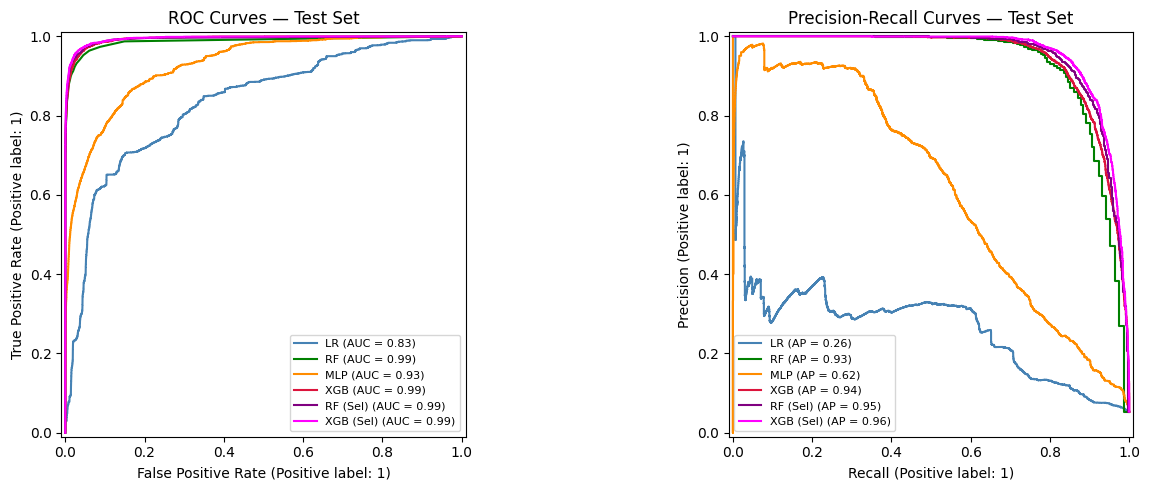

In [ ]:
# ── ROC and Precision-Recall curves for best models on test set ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_proba = [
    ("LR",  cLR,     X_test,     "steelblue"),
    ("RF",  cRF,     X_test,     "green"),
    ("MLP", cMLP,    X_test,     "darkorange"),
    ("XGB", cXGB,    X_test,     "crimson"),
    ("RF (Sel)", cRF_sel, X_test_sel, "purple"),
    ("XGB (Sel)", cXGB_sel, X_test_sel, "magenta"),
]

for name, model, X_te, color in model_proba:
    try:
        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(X_te)[:,1]
        else:
            proba = model.decision_function(X_te)
        RocCurveDisplay.from_predictions(
            y_test.values, proba, name=name, ax=axes[0], color=color)
        PrecisionRecallDisplay.from_predictions(
            y_test.values, proba, name=name, ax=axes[1], color=color)
    except Exception as e:
        print(f"  Could not plot {name}: {e}")

axes[0].set_title("ROC Curves — Test Set")
axes[1].set_title("Precision-Recall Curves — Test Set")
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
# ── Key takeaways ────────────────────────────────────────────────────────────
print("Key takeaways:")
print("  1. Split before scale eliminates MinMaxScaler data leakage")
print("  2. Drop-column importance now uses validation set — rankings")
print("     reflect true generalisation, not training memorisation")
print("  3. TimeSeriesSplit CV gives mean ± std across 5 temporal folds,")
print("     revealing which models are stable vs sensitive to time period")
print("  4. Hyperparameter tuning via CV selects optimal n_estimators")
print(f"     for RF: best = {best_n} trees by CV mean F1")
print("  5. Test set touched only once — final metrics are unbiased")


Key takeaways:
  1. Split before scale eliminates MinMaxScaler data leakage
  2. Drop-column importance now uses validation set — rankings
     reflect true generalisation, not training memorisation
  3. TimeSeriesSplit CV gives mean ± std across 5 temporal folds,
     revealing which models are stable vs sensitive to time period
  4. Hyperparameter tuning via CV selects optimal n_estimators
     for RF: best = 200 trees by CV mean F1
  5. Test set touched only once — final metrics are unbiased


---
## Acknowledgements

Released by: Youssef Elmougy, Ling Liu  
School of Computer Science, Georgia Institute of Technology  
Contact: yelmougy3@gatech.edu

**Citation:**
> Youssef Elmougy and Ling Liu. 2023. Demystifying Fraudulent Transactions and Illicit Nodes
> in the Bitcoin Network for Financial Forensics. In *KDD '23*. ACM.
> https://doi.org/10.1145/3580305.3599803

**GitHub:** https://www.github.com/git-disl/EllipticPlusPlus


In [ ]:
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#